# CSI Pilot Analysis: First Controlled Collection
**Project:** Wi-Fi Sensing Device-Free with CSI on ESP32-S3  
**Author:** Warley Xavier
**Course:** PFC I - Control and Automation Engineering - UFMG 2026/1

---

> **Objective:** Inspect, analyze and document the three pilot sessions collected on 02/05/2026:
>
> - Inspect `.csv` files (integrity, missing values)  
> - Plot CSI amplitude vs. time for 5–10 subcarriers  
> - Visually compare empty vs. occupied patterns  
> - Evaluate stability: phase/amplitude drift without a person  
> - Document effective sampling rate obtained  
> - Identify noisy or anomalous subcarriers  
>
> **Inputs:** 3 `.csv` files + their `_meta.json` generated by `csi_collector_v2`  
> **Outputs:** Plots in `./outputs/` and viability verdict in the final cell.

## Cell 1 - Configuration
Set the paths to the CSVs for the three sessions. JSON files are detected automatically.

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
from pathlib import Path
from datetime import datetime
from scipy import signal as sp_signal
from scipy.stats import kurtosis

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "figure.dpi": 150,
    "font.family": "DejaVu Sans",
    "axes.grid": True,
    "grid.alpha": 0.35,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# -------------------------------------------------------------------
# CONFIGURE PATHS BEFORE RUNNING
# Adjust DATA_DIR if the CSVs are in a different directory.
# -------------------------------------------------------------------

# Locate repo root regardless of where Jupyter was launched from
_p = Path.cwd()
for PROJECT_ROOT in [_p, _p.parent, _p.parent.parent]:
    if (PROJECT_ROOT / 'requirements.txt').exists():
        break

DATA_DIR   = PROJECT_ROOT / 'data' / '01_raw' / 'pilot'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'pilot'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DPI = 200

# Session C - EMPTY environment
PATH_CSV_C  = str(DATA_DIR / "session_C_empty_20260502_1240.csv")
PATH_META_C = None  # auto-detect

# Session D - OCCUPIED environment (person still)
PATH_CSV_D  = str(DATA_DIR / "session_D_occupied_still_20260502_1317.csv")
PATH_META_D = None  # auto-detect

# Session E - OCCUPIED environment (person moving)
PATH_CSV_E  = str(DATA_DIR / "session_E_occupied_moving_20260502_1404.csv")
PATH_META_E = None  # auto-detect

# Session F - EMPTY environment (repeat of Session C at a later time)
PATH_CSV_F = str(DATA_DIR / "session_F_empty_20260503_1537.csv")
PATH_META_F = None  # auto-detect

# Nominal TX rate (Hz) - fallback if JSON is not available
NOMINAL_RATE_HZ = 30

# Color palette by label
LABEL_COLORS = {
    "empty":           "#2196F3",   # blue
    "occupied_still":  "#F44336",   # red
    "occupied_moving": "#FF9800",   # orange
}

for p in [PATH_CSV_C, PATH_CSV_D, PATH_CSV_E, PATH_CSV_F]:
    if not Path(p).exists():
        print(f"[WARNING] File not found: {p}")
    else:
        print(f"[OK] {Path(p).name}")

print(f"\nOUTPUT_DIR: {OUTPUT_DIR.resolve()}")


[OK] session_C_empty_20260502_1240.csv
[OK] session_D_occupied_still_20260502_1317.csv
[OK] session_E_occupied_moving_20260502_1404.csv
[OK] session_F_empty_20260503_1537.csv

OUTPUT_DIR: /home/xavier/code/wifi-csi-presence-detection/pilot/outputs


## Cell 2 - Parsing and Loading Functions
Run once; defines all functions used in subsequent cells.

In [2]:
# --- Timestamp helpers -------------------------------------------------------

TS_HOST_FMT = "%Y%m%dT%H%M%S.%f"

def parse_ts_host(s):
    return pd.to_datetime(s, format=TS_HOST_FMT)

def iso_to_ts(s):
    ts = pd.Timestamp(s)
    return ts.tz_localize(None) if ts.tzinfo is None else ts.tz_convert(None)

# --- CSI parsing -------------------------------------------------------------

def parse_csi_array(data_str):
    try:
        return np.array(json.loads(data_str), dtype=np.int8)
    except Exception:
        return None

def raw_to_complex(raw):
    """ESP32 CSI format: [imag_0, real_0, imag_1, real_1, ...]"""
    return raw[1::2].astype(np.float32) + 1j * raw[0::2].astype(np.float32)

def detect_valid_subcarriers(amp_matrix, threshold=0.5):
    """Returns boolean mask of subcarriers with mean amplitude > threshold."""
    return amp_matrix.mean(axis=0) > threshold

# --- JSON metadata loader ----------------------------------------------------

def find_meta_json(csv_path):
    stem = Path(csv_path).stem
    candidate = Path(csv_path).with_name(stem + "_meta.json")
    return str(candidate) if candidate.exists() else None

def load_meta(json_path):
    if json_path is None:
        return None
    try:
        with open(json_path, encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return None

# --- Main session loader -----------------------------------------------------

def load_session(csv_path, meta_path=None):
    """
    Loads a CSI session, performs full parsing and returns a dict with:
    df, label, meta, timestamps, dt (inter-packet intervals), csi_amp (matrix),
    csi_phase, valid_mask, n_valid, n_subcarriers, eff_rate_hz, duration_s,
    t1, t2 (condition window from JSON, if available)
    """
    # 1. Detect and load JSON
    if meta_path is None:
        meta_path = find_meta_json(csv_path)
    meta = load_meta(meta_path)

    # 2. Read CSV
    df = pd.read_csv(csv_path)
    print(f"  CSV loaded: {Path(csv_path).name}  ->  {len(df)} rows, {df.shape[1]} columns")

    # 3. Timestamps
    df["ts"] = df["timestamp_host"].apply(parse_ts_host)
    df = df.sort_values("ts").reset_index(drop=True)
    timestamps = df["ts"].values  # numpy datetime64
    dt_s = pd.Series(timestamps).diff().dt.total_seconds().dropna()

    # 4. Derive label
    if meta:
        label = meta.get("session", {}).get("label", Path(csv_path).stem)
    else:
        # Try to extract from filename
        stem = Path(csv_path).stem
        if "empty" in stem:
            label = "empty"
        elif "occupied_still" in stem:
            label = "occupied_still"
        elif "occupied_moving" in stem:
            label = "occupied_moving"
        else:
            label = stem

    # 5. CSI parsing
    raw_arrays = df["data"].apply(parse_csi_array)
    valid_rows = raw_arrays.apply(lambda x: x is not None and len(x) >= 2)
    df = df[valid_rows].reset_index(drop=True)
    raw_arrays = raw_arrays[valid_rows].reset_index(drop=True)

    # Determine n_subcarriers from median array length
    arr_lens = raw_arrays.apply(lambda x: len(x) if x is not None else 0)
    n_raw = int(arr_lens.median())
    n_sub = n_raw // 2  # each subcarrier: 2 values (I, Q)

    # Filter rows with correct length
    mask_len = arr_lens == n_raw
    df = df[mask_len].reset_index(drop=True)
    raw_arrays = raw_arrays[mask_len].reset_index(drop=True)
    timestamps = df["ts"].values
    dt_s = pd.Series(timestamps).diff().dt.total_seconds().dropna()

    # Build matrices
    csi_complex = np.vstack([raw_to_complex(r) for r in raw_arrays])  # (N, n_sub)
    csi_amp   = np.abs(csi_complex)
    csi_phase = np.angle(csi_complex)

    # 6. Valid subcarriers
    valid_mask = detect_valid_subcarriers(csi_amp)
    n_valid = valid_mask.sum()

    # 7. Effective rate
    duration_s = dt_s.sum()
    eff_rate_hz = (len(df) - 1) / duration_s if duration_s > 0 else 0

    # 8. Condition window from JSON
    t1 = t2 = None
    if meta:
        try:
            t1 = iso_to_ts(meta["timing"]["t1_condition_start"])
            t2 = iso_to_ts(meta["timing"]["t2_condition_end"])
        except Exception:
            pass

    return {
        "df": df,
        "label": label,
        "meta": meta,
        "timestamps": timestamps,
        "dt": dt_s,
        "csi_amp": csi_amp,
        "csi_phase": csi_phase,
        "valid_mask": valid_mask,
        "n_valid": n_valid,
        "n_subcarriers": n_sub,
        "eff_rate_hz": eff_rate_hz,
        "duration_s": duration_s,
        "t1": t1,
        "t2": t2,
    }

def get_color(label):
    for key, color in LABEL_COLORS.items():
        if key in label:
            return color
    return "#607D8B"

def get_nominal_rate(s):
    if s["meta"]:
        r = s["meta"].get("setup", {}).get("wifi", {}).get("icmp_rate_hz")
        if r:
            return float(r)
    return NOMINAL_RATE_HZ

# Select representative subcarriers for plots
def select_representative_subcarriers(amp_matrix, valid_mask, n=8):
    """
    Selects n valid subcarriers evenly distributed across the spectrum,
    avoiding those with very low or very high variance (discards outliers).
    """
    valid_idxs = np.where(valid_mask)[0]
    if len(valid_idxs) == 0:
        return []
    amp_v = amp_matrix[:, valid_idxs]
    stds = amp_v.std(axis=0)
    # Remove top-5% variance (noisy) and bottom-5% (dead)
    lo, hi = np.percentile(stds, 5), np.percentile(stds, 95)
    filtered = valid_idxs[(stds >= lo) & (stds <= hi)]
    if len(filtered) == 0:
        filtered = valid_idxs
    step = max(1, len(filtered) // n)
    chosen = filtered[::step][:n]
    return list(chosen)

print("Parsing functions loaded.")


Parsing functions loaded.


## Cell 3 - Session Loading
Loads the three sessions and displays an immediate summary.

In [3]:
print("-" * 55)
print("Loading session C (empty)...")
sC = load_session(PATH_CSV_C, PATH_META_C)

print("\nLoading session D (occupied_still)...")
sD = load_session(PATH_CSV_D, PATH_META_D)

print("\nLoading session E (occupied_moving)...")
sE = load_session(PATH_CSV_E, PATH_META_E)

print("\nLoading session F (empty, repeat)...")
sF = load_session(PATH_CSV_F, PATH_META_F)

sessions = {"C": sC, "D": sD, "E": sE, "F": sF}

print("\n" + "-" * 55)
print(f"{'Session':<8} {'Label':<20} {'Samples':>9} {'Duration(s)':>11} {'Eff. rate':>13} {'Valid subcarriers':>17}")
print("-" * 55)
for sid, s in sessions.items():
    print(f"  {sid:<6} {s['label']:<20} {len(s['df']):>9} {s['duration_s']:>11.1f} {s['eff_rate_hz']:>12.2f} Hz {s['n_valid']:>12}")
print("-" * 55)


-------------------------------------------------------
Loading session C (empty)...
  CSV loaded: session_C_empty_20260502_1240.csv  ->  19589 rows, 26 columns

Loading session D (occupied_still)...
  CSV loaded: session_D_occupied_still_20260502_1317.csv  ->  18048 rows, 26 columns

Loading session E (occupied_moving)...
  CSV loaded: session_E_occupied_moving_20260502_1404.csv  ->  18610 rows, 26 columns

Loading session F (empty, repeat)...
  CSV loaded: session_F_empty_20260503_1537.csv  ->  20239 rows, 26 columns

-------------------------------------------------------
Session  Label                  Samples Duration(s)     Eff. rate Valid subcarriers
-------------------------------------------------------
  C      empty                    19589       690.0        28.39 Hz          166
  D      occupied_still           18048       689.9        26.16 Hz          162
  E      occupied_moving          18610       689.9        26.97 Hz          166
  F      empty                    2

## Cell 4 - CSV File Integrity Inspection

**Checklist item:** *Inspect generated `.csv` files (integrity, missing values)*

Checks: shape, missing values per column, amplitude of the `len` field (CSI vector size),
and RSSI statistics.

In [4]:
for sid, s in sessions.items():
    df = s["df"]
    label = s["label"]
    print(f"\n{'='*60}")
    print(f" Session {sid} - {label}")
    print(f"{'='*60}")
    print(f"  Shape                 : {df.shape}")
    print(f"  Total duration        : {s['duration_s']:.1f} s")
    print(f"  Raw subcarriers       : {s['n_subcarriers']}")
    print(f"  Valid subcarriers     : {s['n_valid']}")

    # Missing values
    na_counts = df.isnull().sum()
    na_nonzero = na_counts[na_counts > 0]
    if len(na_nonzero) == 0:
        print(f"  Missing values        : None")
    else:
        print(f"  Missing values        :")
        for col, cnt in na_nonzero.items():
            pct = 100 * cnt / len(df)
            print(f"    {col}: {cnt} ({pct:.1f}%)")

    # Distribution of 'len' field
    if "len" in df.columns:
        vc = df["len"].value_counts()
        dominant = vc.index[0]
        dom_pct = 100 * vc.iloc[0] / len(df)
        print(f"  Field 'len'           : dominant value = {dominant} ({dom_pct:.1f}% of rows)")

    # RSSI
    rssi = df["rssi"].dropna()
    print(f"  RSSI                  : mean={rssi.mean():.1f} dBm | std={rssi.std():.2f} dBm | "
          f"min={rssi.min():.0f} dBm | max={rssi.max():.0f} dBm")

    # Temporal gaps (gaps > 2.5x nominal period)
    nom = get_nominal_rate(s)
    dt_nom = 1.0 / nom
    gaps = s["dt"][s["dt"] > 2.5 * dt_nom]
    lost_est = max(0, int(np.round(gaps.sum() / dt_nom)) - len(gaps))
    exp_pkts = int(np.round(s["duration_s"] * nom))
    loss_pct = 100 * lost_est / max(exp_pkts, 1)
    print(f"  Packets received      : {len(df)} / expected approx. {exp_pkts}")
    print(f"  Packets lost          : approx. {lost_est} ({loss_pct:.2f}%)")
    print(f"  Gaps (>2.5x dt)       : {len(gaps)} events")
    print(f"  Jitter                : std = {s['dt'].std()*1000:.2f} ms")

print("\nInspection complete.")



 Session C - empty
  Shape                 : (19589, 27)
  Total duration        : 690.0 s
  Raw subcarriers       : 192
  Valid subcarriers     : 166
  Missing values        : None
  Field 'len'           : dominant value = 384 (100.0% of rows)
  RSSI                  : mean=-33.5 dBm | std=0.50 dBm | min=-34 dBm | max=-33 dBm
  Packets received      : 19589 / expected approx. 20699
  Packets lost          : approx. 34 (0.16%)
  Gaps (>2.5x dt)       : 16 events
  Jitter                : std = 7.41 ms

 Session D - occupied_still
  Shape                 : (18048, 27)
  Total duration        : 689.9 s
  Raw subcarriers       : 192
  Valid subcarriers     : 162
  Missing values        : None
  Field 'len'           : dominant value = 384 (100.0% of rows)
  RSSI                  : mean=-44.5 dBm | std=1.57 dBm | min=-55 dBm | max=-41 dBm
  Packets received      : 18048 / expected approx. 20698
  Packets lost          : approx. 482 (2.33%)
  Gaps (>2.5x dt)       : 228 events
  Jitter   

## Cell 5 - Plot 1: RSSI vs. Time (3 Sessions)

RF link quality reference for each condition.

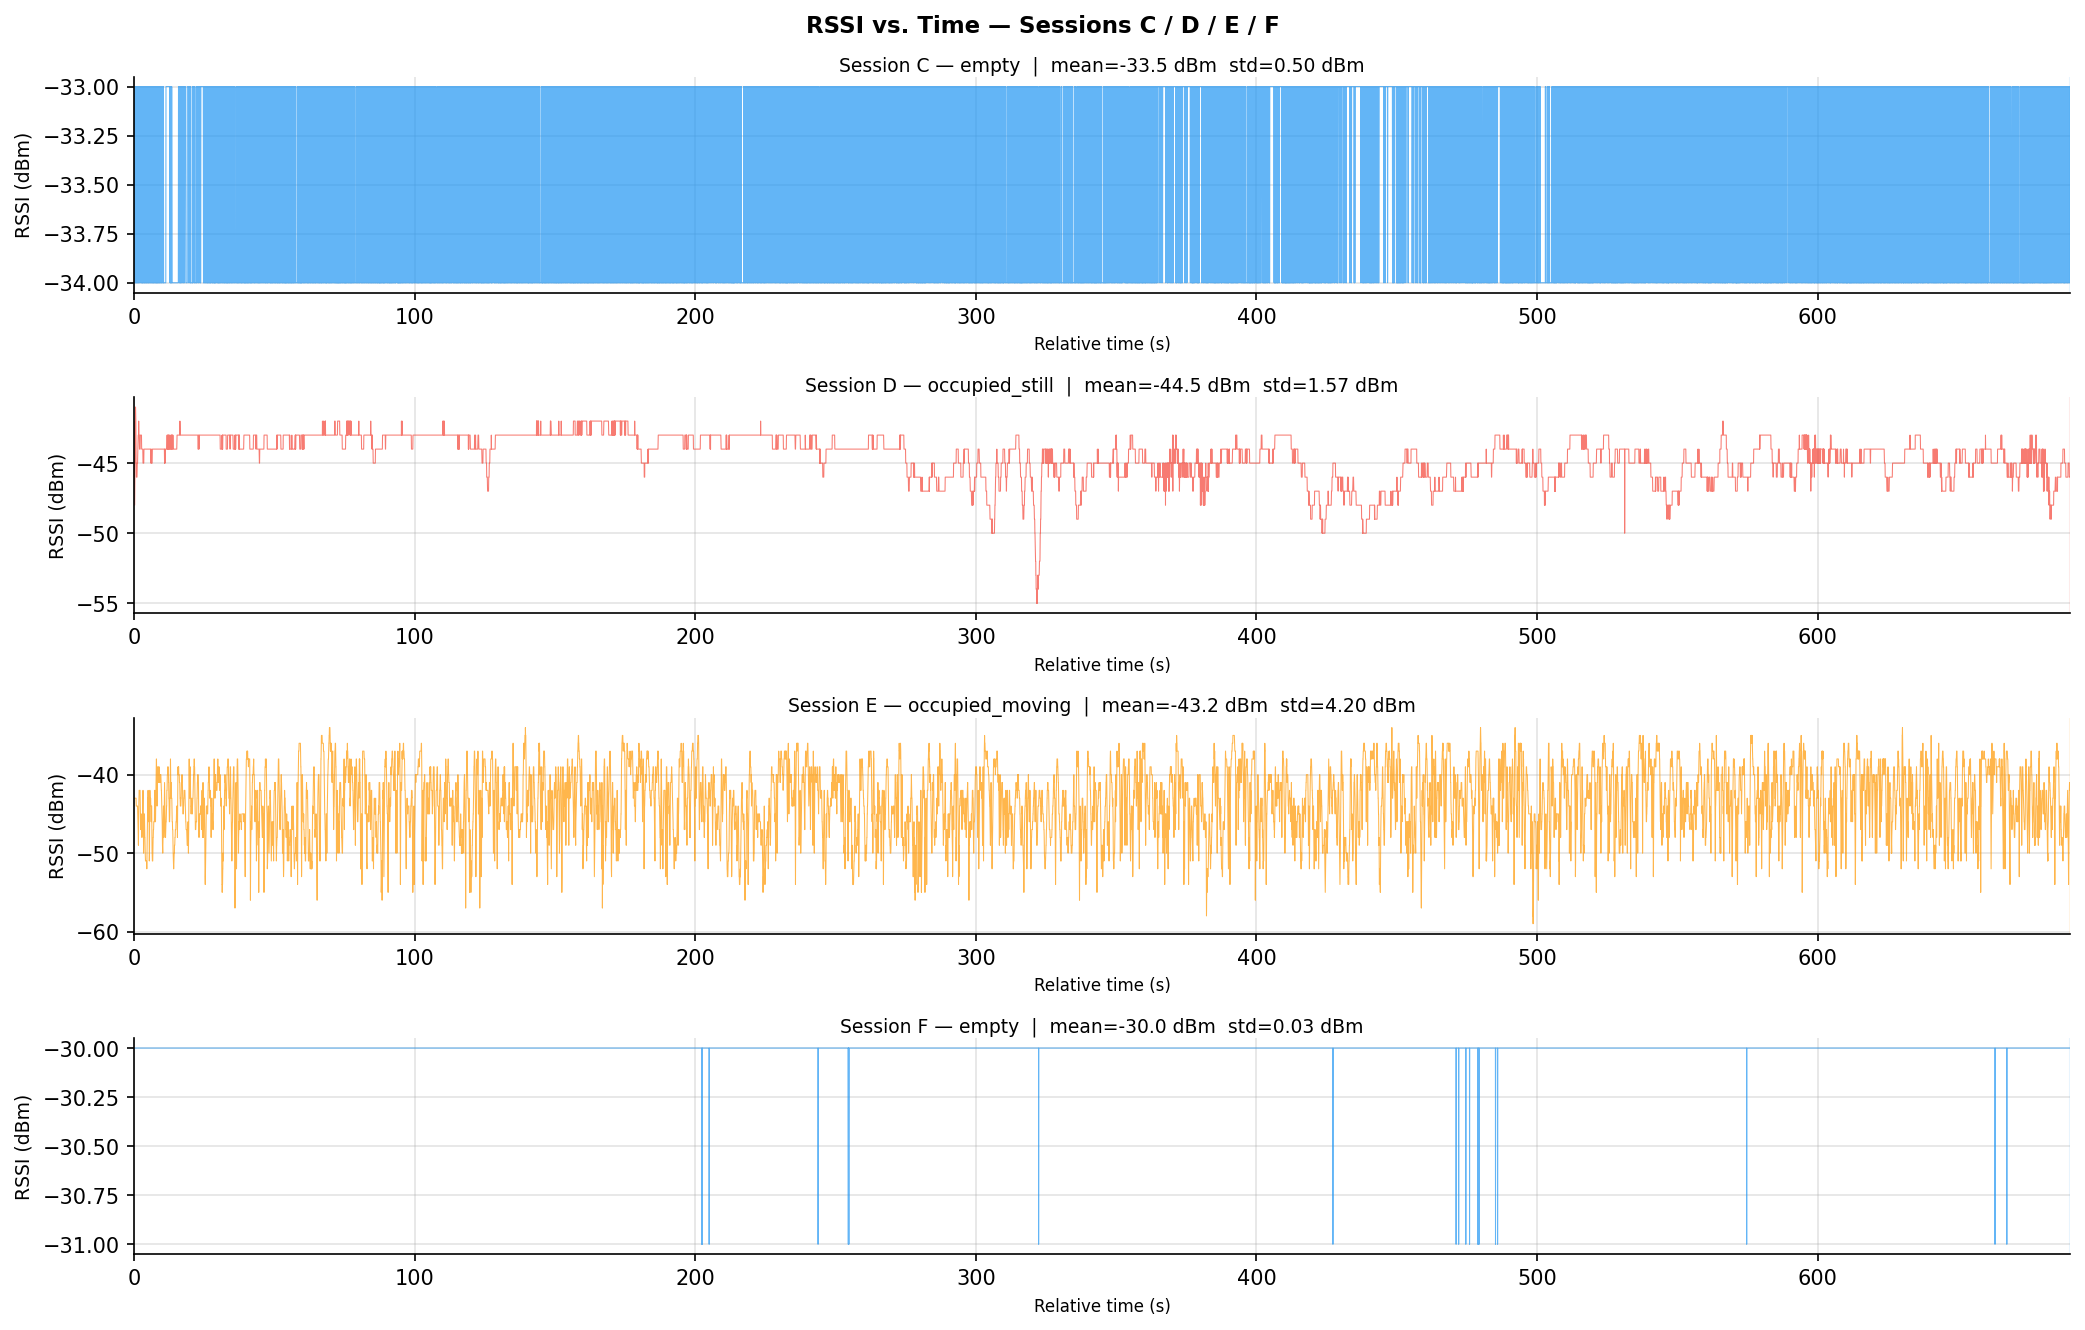

Saved: outputs/plot1_rssi_vs_time.png


In [5]:
fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=False)

for ax, (sid, s) in zip(axes, sessions.items()):
    ts = pd.DatetimeIndex(s["timestamps"])
    t_rel = (ts - ts[0]).total_seconds()
    rssi = s["df"]["rssi"].values
    color = get_color(s["label"])
    ax.plot(t_rel, rssi, lw=0.5, alpha=0.7, color=color)
    ax.set_xlim(0, t_rel[-1])
    ax.set_ylabel("RSSI (dBm)", fontsize=9)
    ax.set_title(f"Session {sid} - {s['label']}  |  mean={rssi.mean():.1f} dBm  std={rssi.std():.2f} dBm",
                 fontsize=9, pad=3)
    # Mark condition window
    if s["t1"] and s["t2"]:
        ts_start = (s["t1"] - pd.Timestamp(ts[0])).total_seconds()
        ts_end   = (s["t2"] - pd.Timestamp(ts[0])).total_seconds()
        ax.axvspan(max(ts_start,0), min(ts_end, t_rel[-1]), alpha=0.10, color=color, label="condition window")
    ax.set_xlabel("Relative time (s)", fontsize=8)

fig.suptitle("RSSI vs. Time - Sessions C / D / E / F", fontsize=11, fontweight="bold")
plt.tight_layout()
fpath = OUTPUT_DIR / "plot1_rssi_vs_time.png"
plt.savefig(fpath, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {fpath}")


## Cell 6 - Plot 2: Amplitude Profile per Subcarrier

Identifies dead subcarriers (guard bands, DC) and compares the mean amplitude spectrum across the three conditions.

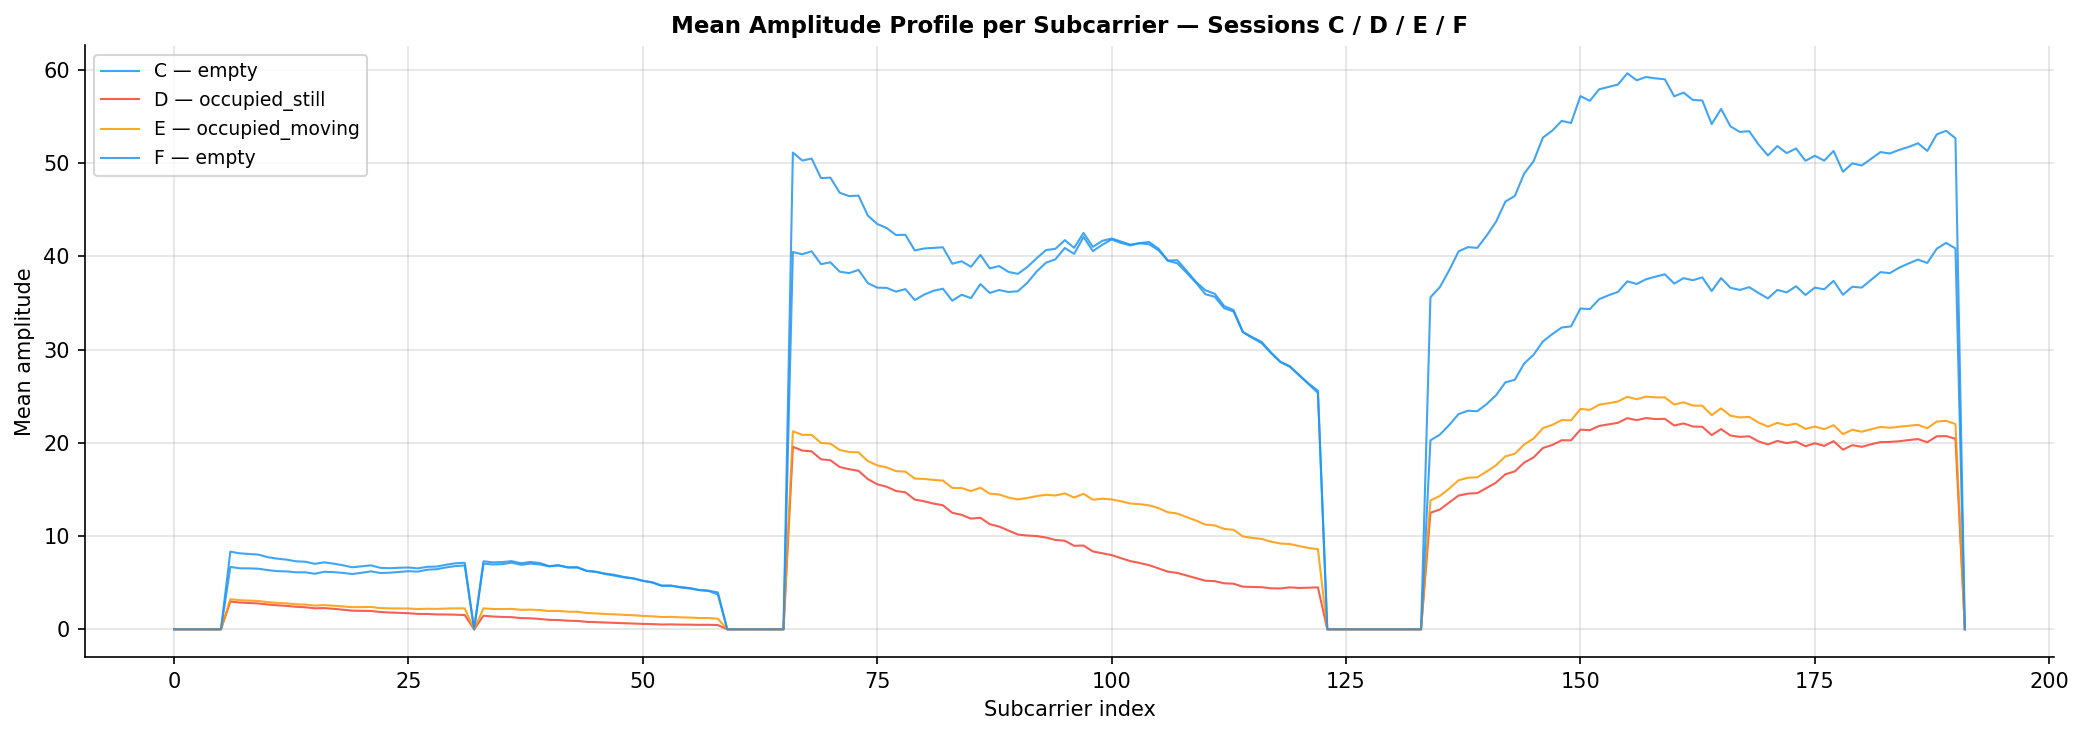

Saved: outputs/plot2_amplitude_per_subcarrier.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

for sid, s in sessions.items():
    amp_mean = s["csi_amp"].mean(axis=0)
    subcarrier_idx = np.arange(len(amp_mean))
    ax.plot(subcarrier_idx, amp_mean, lw=1.0,
            color=get_color(s["label"]), label=f"{sid} - {s['label']}", alpha=0.85)
ax.set_xlabel("Subcarrier index", fontsize=10)
ax.set_ylabel("Mean amplitude", fontsize=10)
ax.set_title("Mean Amplitude Profile per Subcarrier - Sessions C / D / E / F", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)

fpath = OUTPUT_DIR / "plot2_amplitude_per_subcarrier.png"
plt.tight_layout()
plt.savefig(fpath, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {fpath}")


## Cell 7 - Plot 3: CSI Amplitude vs. Time - 8 Representative Subcarriers

**Checklist item:** *Plot CSI amplitude vs. time for 5–10 subcarriers*

For each session, displays the 8 representative subcarriers (discarding guard bands and variance outliers).

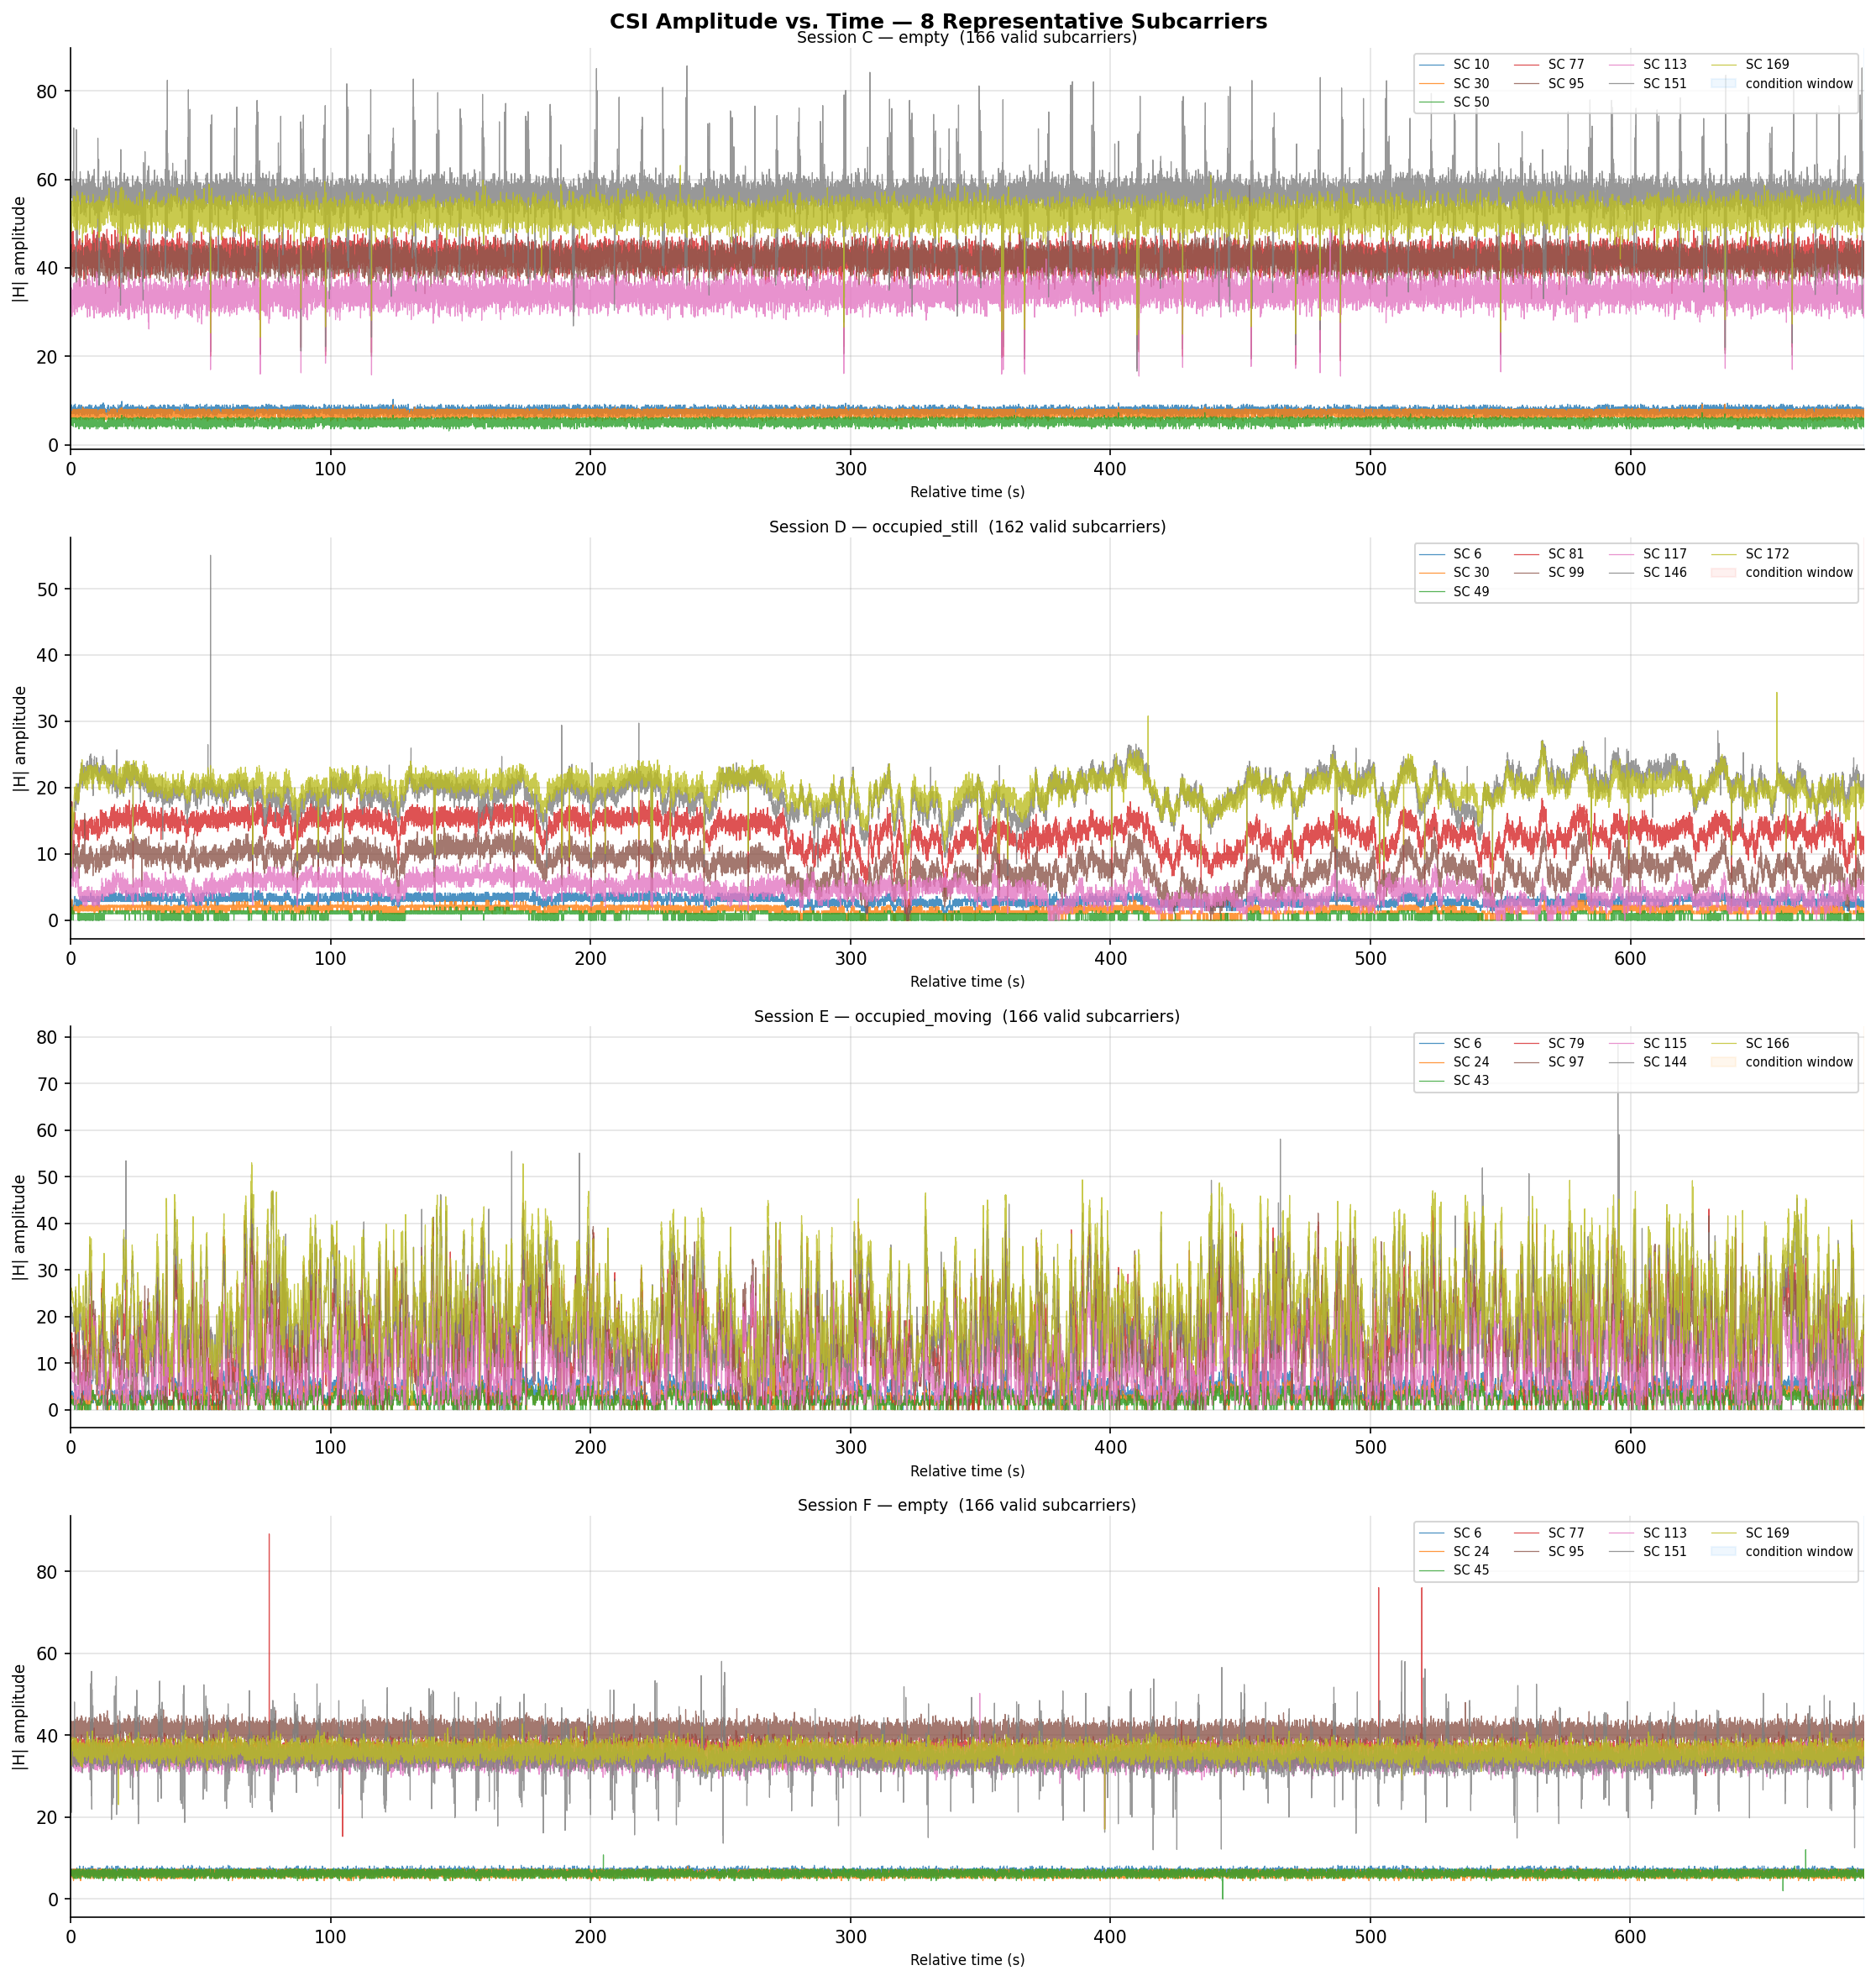

Saved: outputs/plot3_amplitude_vs_time_subcarriers.png


In [7]:
N_SUB_PLOT = 8

fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=False)

for ax, (sid, s) in zip(axes, sessions.items()):
    ts = pd.DatetimeIndex(s["timestamps"])
    t_rel = (ts - ts[0]).total_seconds()
    chosen = select_representative_subcarriers(s["csi_amp"], s["valid_mask"], n=N_SUB_PLOT)

    cmap = plt.cm.tab10
    for i, sc_idx in enumerate(chosen):
        amp = s["csi_amp"][:, sc_idx]
        ax.plot(t_rel, amp, lw=0.6, alpha=0.8,
                color=cmap(i / N_SUB_PLOT), label=f"SC {sc_idx}")

    if s["t1"] and s["t2"]:
        ts_start = (s["t1"] - pd.Timestamp(ts[0])).total_seconds()
        ts_end   = (s["t2"] - pd.Timestamp(ts[0])).total_seconds()
        ax.axvspan(max(ts_start,0), min(ts_end, t_rel[-1]), alpha=0.07,
                   color=get_color(s["label"]), label="condition window")

    ax.set_xlim(0, t_rel[-1])
    ax.set_ylabel("|H| amplitude", fontsize=9)
    ax.set_title(f"Session {sid} - {s['label']}  ({s['n_valid']} valid subcarriers)", fontsize=9, pad=3)
    ax.legend(fontsize=7, ncol=4, loc="upper right")
    ax.set_xlabel("Relative time (s)", fontsize=8)

fig.suptitle("CSI Amplitude vs. Time - 8 Representative Subcarriers", fontsize=12, fontweight="bold")
plt.tight_layout()
fpath = OUTPUT_DIR / "plot3_amplitude_vs_time_subcarriers.png"
plt.savefig(fpath, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {fpath}")


## Cell 8 - Plot 4: Visual Comparison - Empty vs. Occupied

**Checklist item:** *Visually compare empty vs. occupied patterns*

Displays the same reference subcarriers (from session C) for all three conditions in side-by-side subplots.

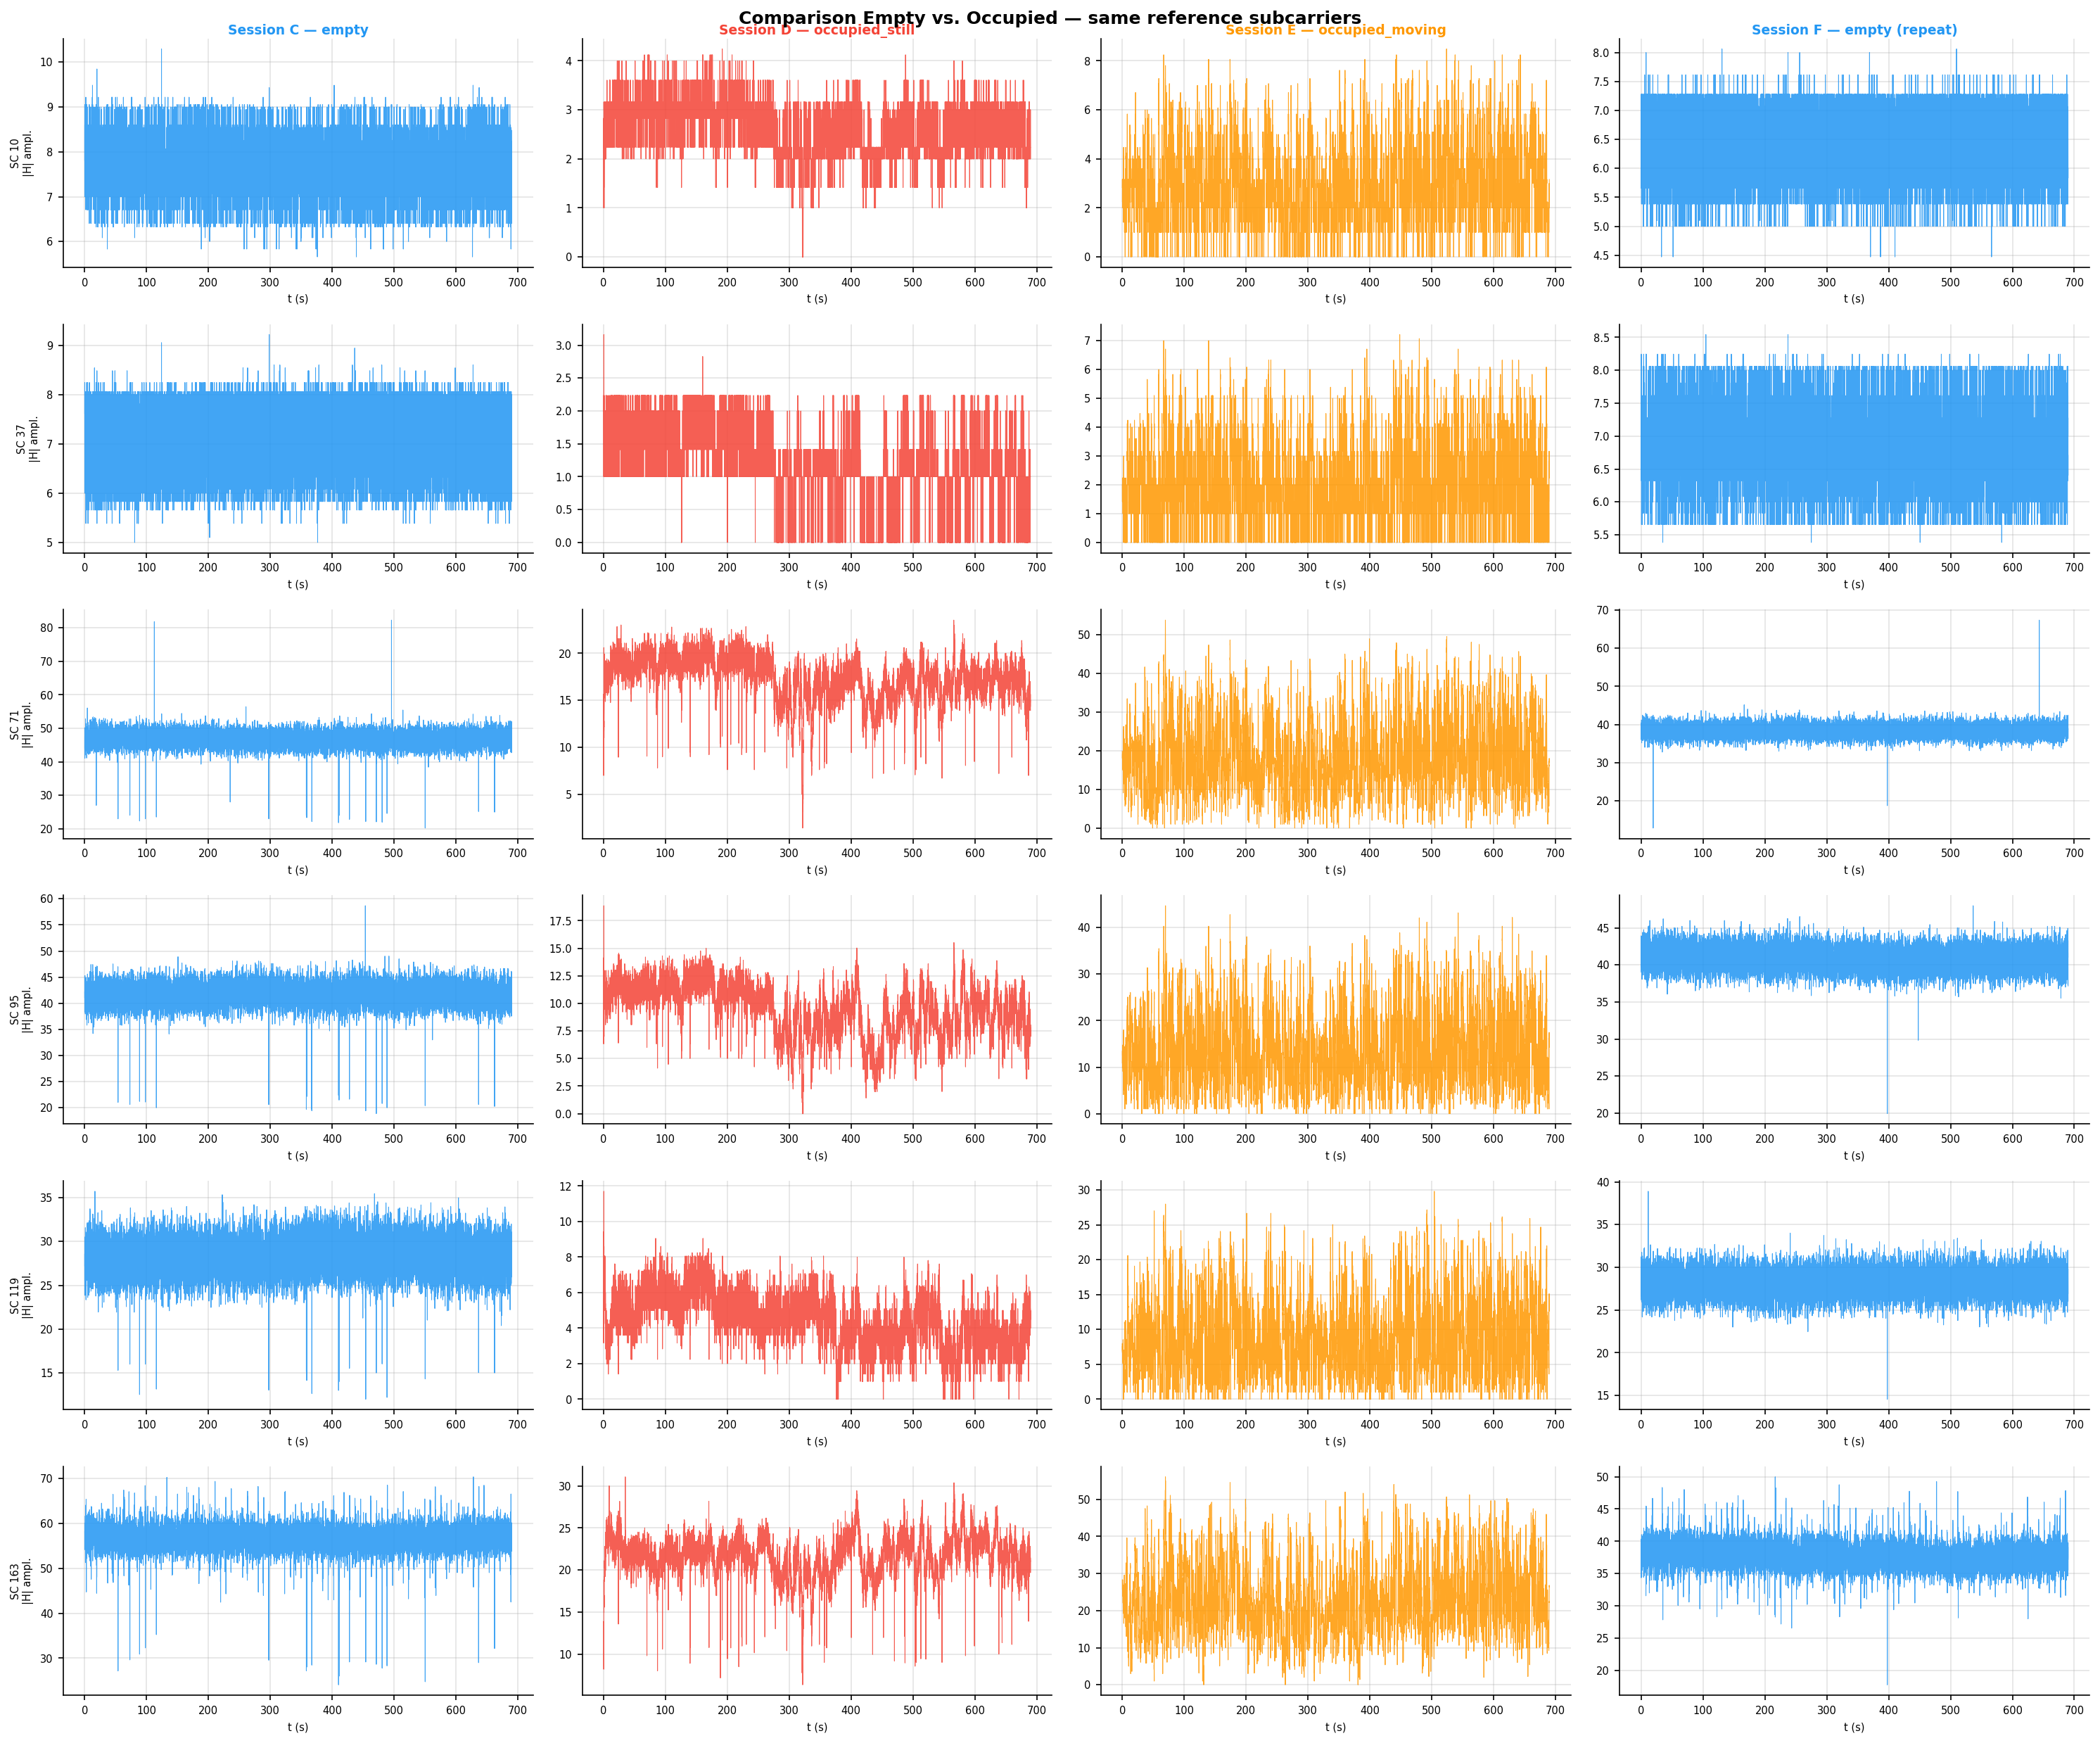

Saved: outputs/plot4_comparison_empty_occupied.png


In [8]:
# Use representative subcarriers from session C as reference
ref_subcarriers = select_representative_subcarriers(sC["csi_amp"], sC["valid_mask"], n=6)
n_sc = len(ref_subcarriers)
fig, axes = plt.subplots(n_sc, 4, figsize=(20, 2.8 * n_sc), sharex=False)

session_list = [("C", sC), ("D", sD), ("E", sE), ("F", sF)]
col_titles   = ["Session C - empty", "Session D - occupied_still",
                "Session E - occupied_moving", "Session F - empty (repeat)"]

for col_idx, (sid, s) in enumerate(session_list):
    ts = pd.DatetimeIndex(s["timestamps"])
    t_rel = (ts - ts[0]).total_seconds()
    for row_idx, sc_idx in enumerate(ref_subcarriers):
        ax = axes[row_idx][col_idx] if n_sc > 1 else axes[col_idx]
        # Use the equivalent subcarrier in each session (same relative position)
        # If sc_idx is out of range for the current session, use the last valid one
        if sc_idx < s["csi_amp"].shape[1]:
            amp = s["csi_amp"][:, sc_idx]
        else:
            amp = s["csi_amp"][:, -1]
        ax.plot(t_rel, amp, lw=0.5, alpha=0.85, color=get_color(s["label"]))
        if row_idx == 0:
            ax.set_title(col_titles[col_idx], fontsize=9, pad=3, fontweight="bold",
                         color=get_color(s["label"]))
        if col_idx == 0:
            ax.set_ylabel(f"SC {sc_idx}\n|H| ampl.", fontsize=7)
        ax.set_xlabel("t (s)", fontsize=7)
        ax.tick_params(labelsize=7)

fig.suptitle("Comparison Empty vs. Occupied - same reference subcarriers", fontsize=12, fontweight="bold")
plt.tight_layout()
fpath = OUTPUT_DIR / "plot4_comparison_empty_occupied.png"
plt.savefig(fpath, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {fpath}")


## Cell 9 - Plot 5: Stability - Amplitude and Phase Drift (Empty Session)

**Checklist item:** *Evaluate stability: check for phase/amplitude drift without a person*

Analysis of session C (empty): rolling mean of amplitude and phase over time, and cumulative standard deviation.

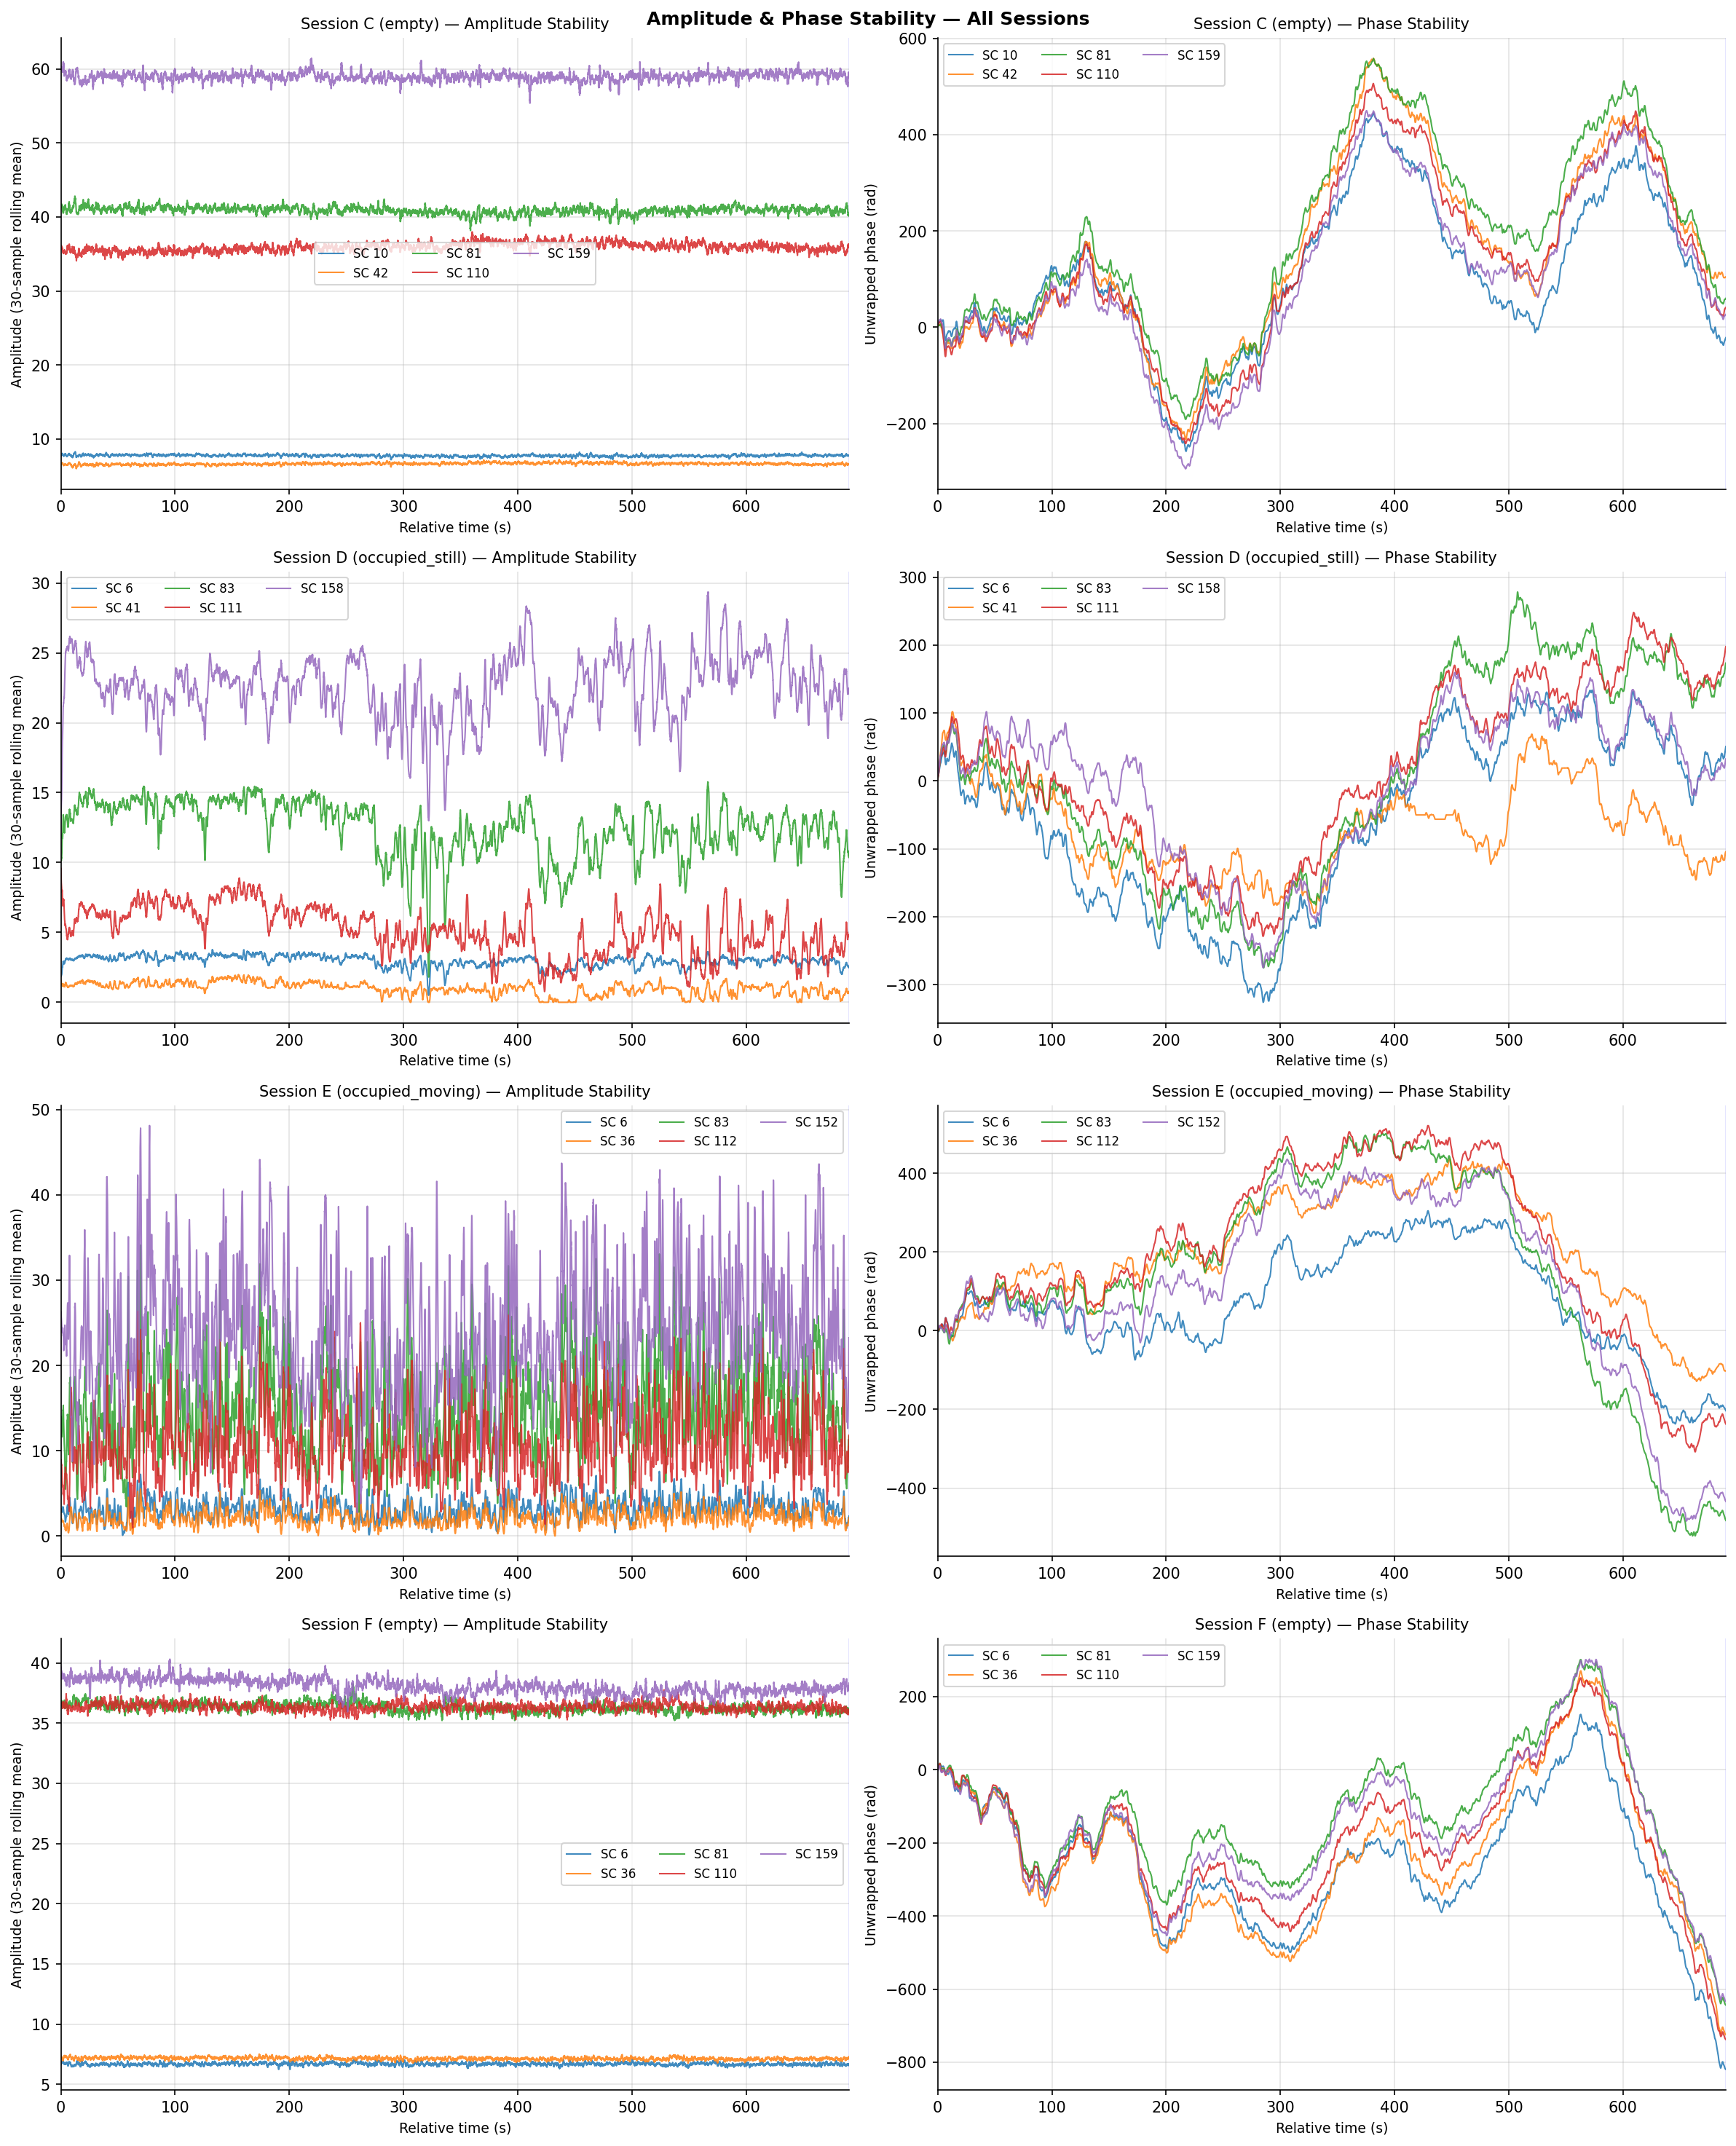

Saved: outputs/plot5_stability_amplitude_phase.png


In [9]:

fig, axes = plt.subplots(len(sessions), 2, figsize=(16, 5 * len(sessions)))

for row_idx, (sid, s) in enumerate(sessions.items()):
    ts = pd.DatetimeIndex(s["timestamps"])
    t_rel = (ts - ts[0]).total_seconds()
    chosen = select_representative_subcarriers(s["csi_amp"], s["valid_mask"], n=5)

    ax_amp = axes[row_idx, 0]
    ax_ph  = axes[row_idx, 1]

    t1_val = t2_val = None
    if s["t1"] and s["t2"]:
        t1_val = (s["t1"] - pd.Timestamp(ts[0])).total_seconds()
        t2_val = (s["t2"] - pd.Timestamp(ts[0])).total_seconds()

    # --- Amplitude -----------------------------------------------------------
    for sc_idx in chosen:
        amp = s["csi_amp"][:, sc_idx]
        amp_smooth = pd.Series(amp).rolling(30, center=True, min_periods=1).mean()
        ax_amp.plot(t_rel, amp_smooth, lw=1.0, label=f"SC {sc_idx}", alpha=0.85)
    ax_amp.set_xlim(0, t_rel[-1])
    ax_amp.set_xlabel("Relative time (s)", fontsize=9)
    ax_amp.set_ylabel("Amplitude (30-sample rolling mean)", fontsize=9)
    ax_amp.set_title(f"Session {sid} ({s['label']}) - Amplitude Stability", fontsize=10)
    ax_amp.legend(fontsize=8, ncol=3)
    if t1_val is not None:
        ax_amp.axvspan(max(t1_val, 0), min(t2_val, t_rel[-1]), alpha=0.1, color="blue")

    # --- Phase (unwrapped) ---------------------------------------------------
    for sc_idx in chosen:
        ph = s["csi_phase"][:, sc_idx]
        ph_unw = np.unwrap(ph)
        ph_smooth = pd.Series(ph_unw).rolling(30, center=True, min_periods=1).mean()
        ax_ph.plot(t_rel, ph_smooth, lw=1.0, label=f"SC {sc_idx}", alpha=0.85)
    ax_ph.set_xlim(0, t_rel[-1])
    ax_ph.set_ylabel("Unwrapped phase (rad)", fontsize=9)
    ax_ph.set_xlabel("Relative time (s)", fontsize=9)
    ax_ph.set_title(f"Session {sid} ({s['label']}) - Phase Stability", fontsize=10)
    ax_ph.legend(fontsize=8, ncol=3)
    if t1_val is not None:
        ax_ph.axvspan(max(t1_val, 0), min(t2_val, t_rel[-1]), alpha=0.1, color="blue")

fig.suptitle("Amplitude & Phase Stability - All Sessions", fontsize=12, fontweight="bold")
plt.tight_layout()
fpath = OUTPUT_DIR / "plot5_stability_amplitude_phase.png"
plt.savefig(fpath, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {fpath}")


## Cell 10 - Effective Sampling Rate

**Checklist item:** *Document effective sampling rate obtained*

Calculates the effective rate for each session and displays a histogram of inter-packet intervals.

Session  Label                      Samples  Dur. (s)  Eff. rate (Hz)  Jitter (ms)
  C      empty                        19589     690.0         28.390         7.41
         Nominal rate: 30 Hz  |  Relative deviation: 5.37%
  D      occupied_still               18048     689.9         26.157        13.24
         Nominal rate: 30 Hz  |  Relative deviation: 12.81%
  E      occupied_moving              18610     689.9         26.972        11.49
         Nominal rate: 30 Hz  |  Relative deviation: 10.09%
  F      empty                        20239     690.0         29.332         3.60
         Nominal rate: 30 Hz  |  Relative deviation: 2.23%


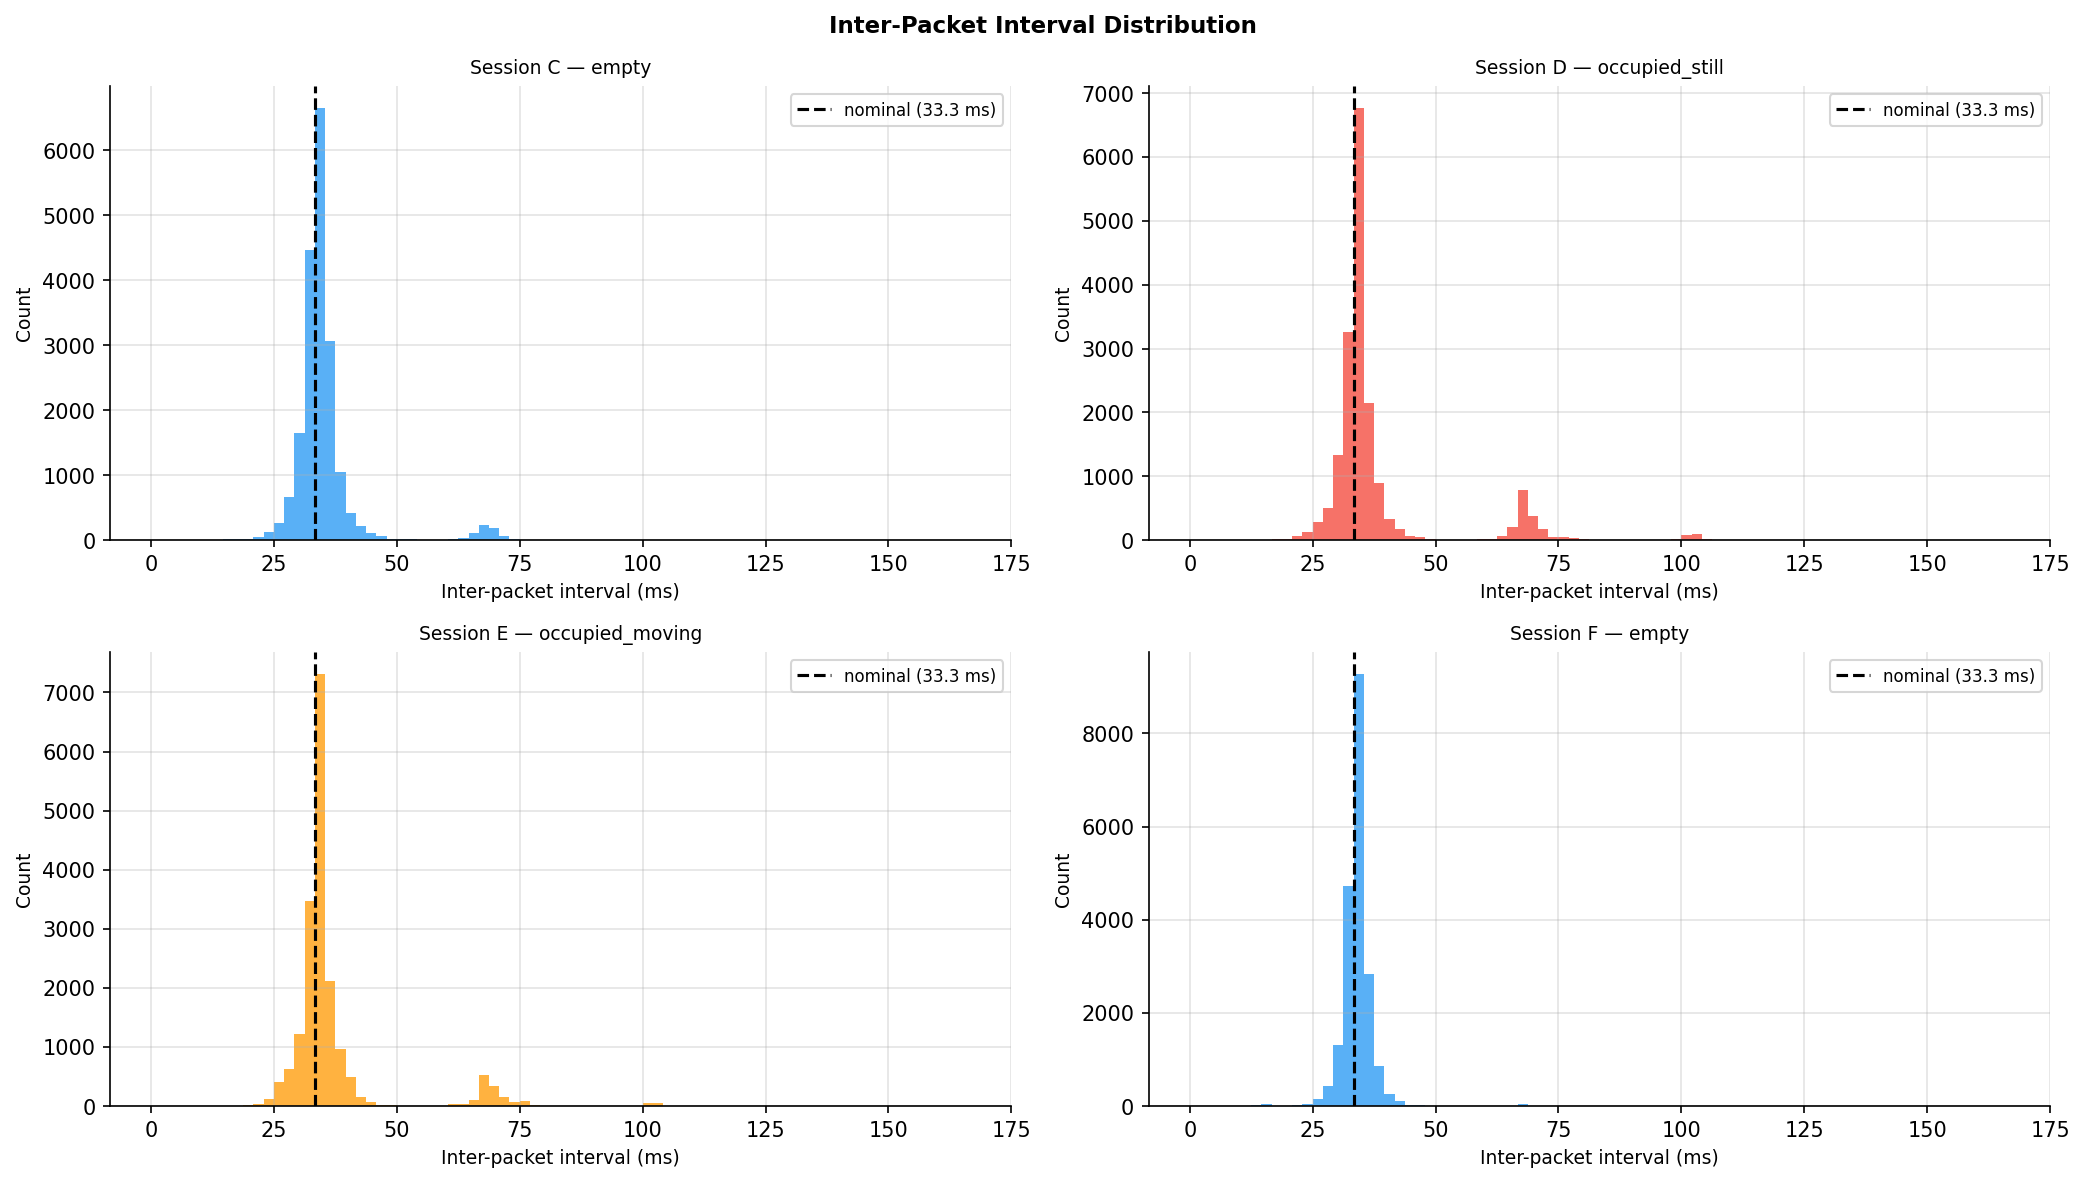

Saved: outputs/plot6_interpacket_intervals.png


In [10]:

print("=" * 65)
print(f"{'Session':<8} {'Label':<22} {'Samples':>11} {'Dur. (s)':>9} {'Eff. rate (Hz)':>15} {'Jitter (ms)':>12}")
print("=" * 65)
for sid, s in sessions.items():
    nom = get_nominal_rate(s)
    print(f"  {sid:<6} {s['label']:<22} {len(s['df']):>11} {s['duration_s']:>9.1f} "
          f"{s['eff_rate_hz']:>14.3f} {s['dt'].std()*1000:>12.2f}")
    print(f"{'':>8} Nominal rate: {nom:.0f} Hz  |  Relative deviation: "
          f"{abs(s['eff_rate_hz']-nom)/nom*100:.2f}%")
print("=" * 65)

# Inter-packet interval histogram - 2×2 grid for 4 sessions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for ax, (sid, s) in zip(axes, sessions.items()):
    dt_ms = s["dt"] * 1000
    nom_ms = 1000.0 / get_nominal_rate(s)
    ax.hist(dt_ms, bins=80, range=(0, nom_ms * 5), color=get_color(s["label"]), alpha=0.75, edgecolor="none")
    ax.axvline(nom_ms, color="black", lw=1.5, ls="--", label=f"nominal ({nom_ms:.1f} ms)")
    ax.set_xlabel("Inter-packet interval (ms)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.set_title(f"Session {sid} - {s['label']}", fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle("Inter-Packet Interval Distribution", fontsize=11, fontweight="bold")
plt.tight_layout()
fpath = OUTPUT_DIR / "plot6_interpacket_intervals.png"
plt.savefig(fpath, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {fpath}")


## Cell 11 - Noisy or Anomalous Subcarrier Identification

**Checklist item:** *Identify noisy or anomalous subcarriers*

Metrics per subcarrier: coefficient of variation (CV), kurtosis, and cross-session correlation.


-- Noisy subcarrier analysis -- Session C (empty) as reference --
  Total subcarriers      : 192
  Valid subcarriers      : 166
  Dead subcarriers       : 26  (guard bands / DC)
  Noisy (CV > p90)       : 17  indices: [np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55)]...
  Anomalous (|kurt| > 5.0) : 106  indices: [np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75)]...


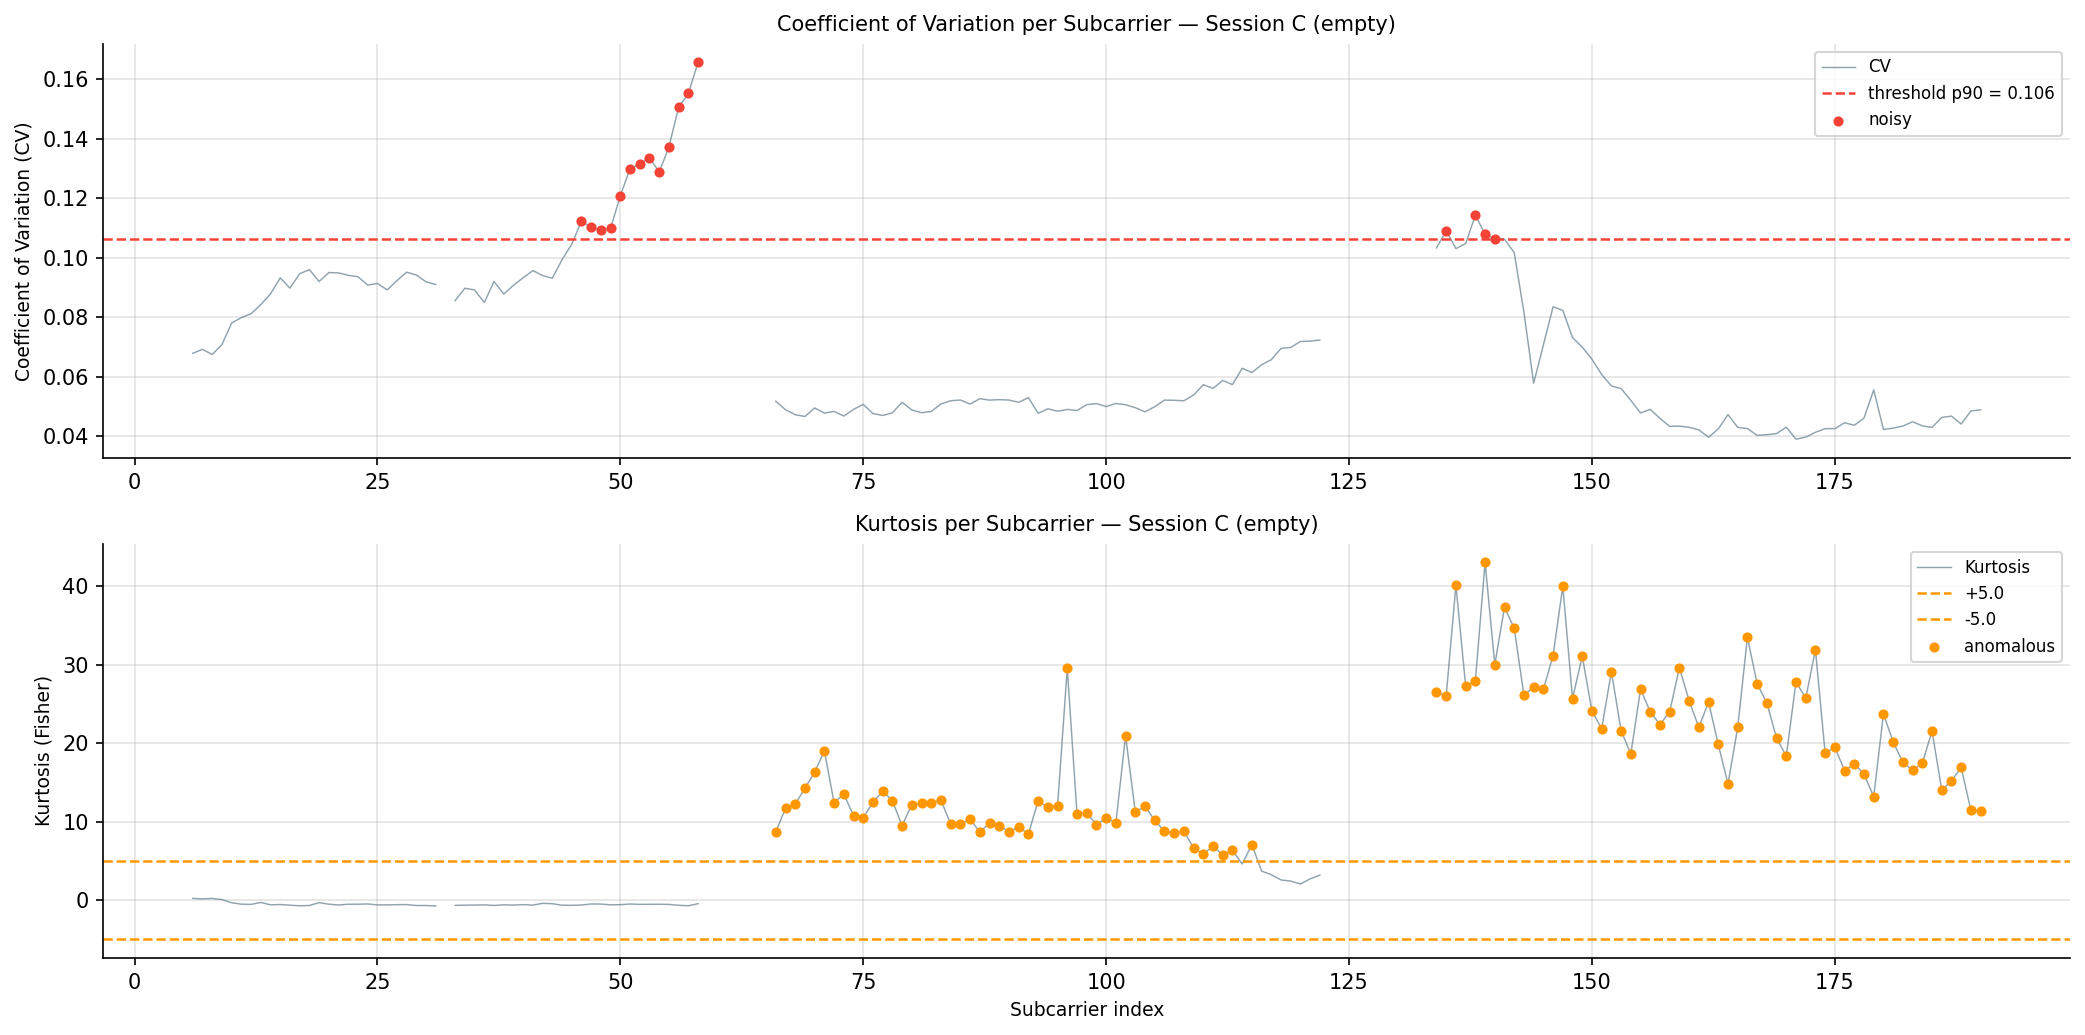

Saved: outputs/plot7_noisy_subcarriers.png


In [11]:
from scipy.stats import kurtosis as scipy_kurtosis

print("\n-- Noisy subcarrier analysis -- Session C (empty) as reference --")

s_ref = sC
amp_all = s_ref["csi_amp"]   # (N, n_sub)
n_sub = amp_all.shape[1]

# Metrics per subcarrier
mean_amp  = amp_all.mean(axis=0)
std_amp   = amp_all.std(axis=0)
cv        = np.where(mean_amp > 0.1, std_amp / mean_amp, np.nan)  # coefficient of variation
kurt      = np.array([scipy_kurtosis(amp_all[:, i], fisher=True) for i in range(n_sub)])
valid_mask = s_ref["valid_mask"]

# Classify as noisy: CV > 90th percentile among valid subcarriers
cv_valid = cv[valid_mask]
thresh_cv = np.nanpercentile(cv_valid, 90)

# Classify as anomalous: |kurtosis| > 5 (very heavy tails)
thresh_kurt = 5.0

noisy_sc     = np.where(valid_mask & (cv > thresh_cv))[0]
anomalous_sc = np.where(valid_mask & (np.abs(kurt) > thresh_kurt))[0]
dead_sc      = np.where(~valid_mask)[0]

print(f"  Total subcarriers      : {n_sub}")
print(f"  Valid subcarriers      : {valid_mask.sum()}")
print(f"  Dead subcarriers       : {len(dead_sc)}  (guard bands / DC)")
print(f"  Noisy (CV > p90)       : {len(noisy_sc)}  indices: {list(noisy_sc[:10])}{'...' if len(noisy_sc)>10 else ''}")
print(f"  Anomalous (|kurt| > {thresh_kurt}) : {len(anomalous_sc)}  indices: {list(anomalous_sc[:10])}{'...' if len(anomalous_sc)>10 else ''}")

# --- Plot: CV and Kurtosis per subcarrier ------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

ax1 = axes[0]
ax1.plot(np.arange(n_sub), cv, lw=0.7, color="#607D8B", alpha=0.7, label="CV")
ax1.axhline(thresh_cv, color="#F44336", lw=1.2, ls="--", label=f"threshold p90 = {thresh_cv:.3f}")
ax1.scatter(noisy_sc, cv[noisy_sc], color="#F44336", s=15, zorder=5, label="noisy")
ax1.set_ylabel("Coefficient of Variation (CV)", fontsize=9)
ax1.set_title("Coefficient of Variation per Subcarrier - Session C (empty)", fontsize=10)
ax1.legend(fontsize=8)

ax2 = axes[1]
ax2.plot(np.arange(n_sub), kurt, lw=0.7, color="#607D8B", alpha=0.7, label="Kurtosis")
ax2.axhline(thresh_kurt, color="#FF9800", lw=1.2, ls="--", label=f"+{thresh_kurt}")
ax2.axhline(-thresh_kurt, color="#FF9800", lw=1.2, ls="--", label=f"-{thresh_kurt}")
ax2.scatter(anomalous_sc, kurt[anomalous_sc], color="#FF9800", s=15, zorder=5, label="anomalous")
ax2.set_ylabel("Kurtosis (Fisher)", fontsize=9)
ax2.set_xlabel("Subcarrier index", fontsize=9)
ax2.set_title("Kurtosis per Subcarrier - Session C (empty)", fontsize=10)
ax2.legend(fontsize=8)

plt.tight_layout()
fpath = OUTPUT_DIR / "plot7_noisy_subcarriers.png"
plt.savefig(fpath, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {fpath}")


## Cell 12 - Plot 8: CSI Amplitude Heatmap (subcarriers × time)

Compact visualization of the full CSI matrix for all 3 sessions.

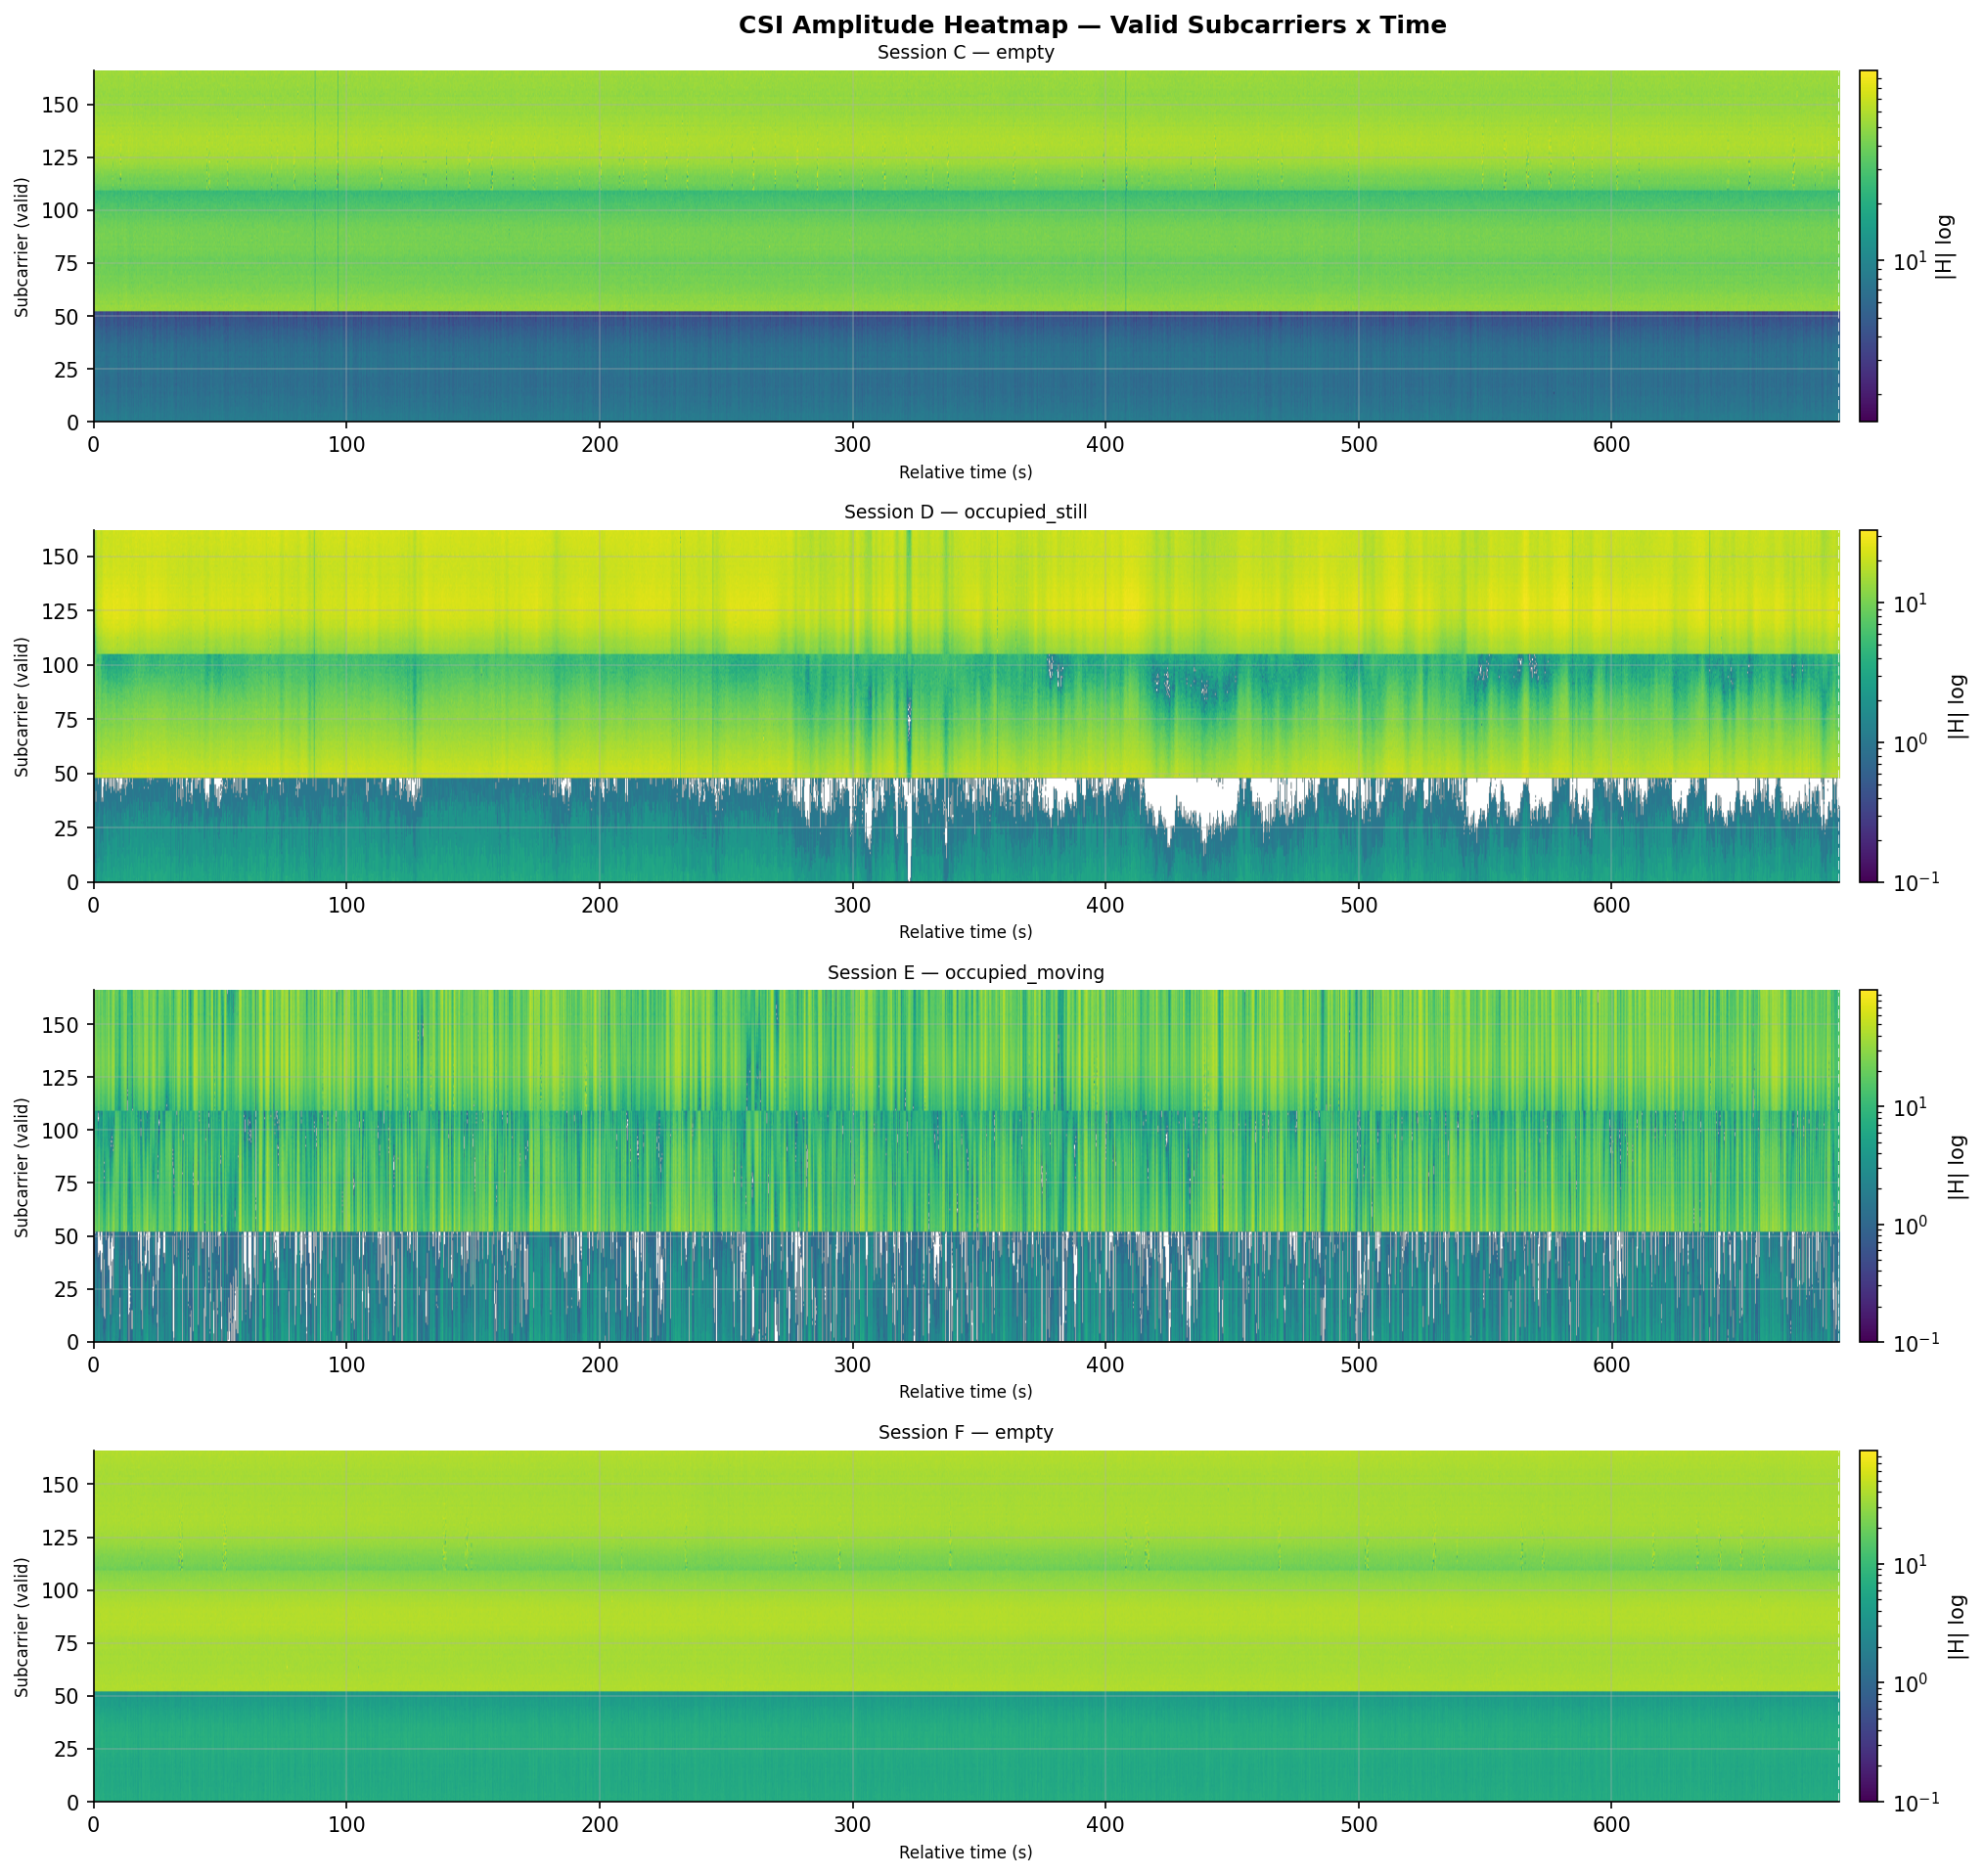

Saved: outputs/plot8_heatmap_amplitude.png


In [12]:

fig, axes = plt.subplots(4, 1, figsize=(15, 13))

for ax, (sid, s) in zip(axes, sessions.items()):
    # Use only valid subcarriers and downsample in time for visualization
    amp_valid = s["csi_amp"][:, s["valid_mask"]]
    # Downsample to at most 3000 time samples
    step = max(1, amp_valid.shape[0] // 3000)
    amp_plot = amp_valid[::step, :].T  # (n_valid, T_downsampled)
    ts = pd.DatetimeIndex(s["timestamps"])
    t_rel = (ts - ts[0]).total_seconds()

    im = ax.imshow(amp_plot, aspect="auto", origin="lower",
                   extent=[0, t_rel[-1], 0, amp_valid.shape[1]],
                   cmap="viridis", norm=LogNorm(vmin=max(0.1, amp_plot.min()+0.01),
                                                vmax=amp_plot.max()))
    ax.set_ylabel("Subcarrier (valid)", fontsize=8)
    ax.set_xlabel("Relative time (s)", fontsize=8)
    ax.set_xlim(0, t_rel[-1])
    ax.set_title(f"Session {sid} - {s['label']}", fontsize=9)
    plt.colorbar(im, ax=ax, pad=0.01, label="|H| log")

    if s["t1"] and s["t2"]:
        t1 = (s["t1"] - pd.Timestamp(ts[0])).total_seconds()
        t2 = (s["t2"] - pd.Timestamp(ts[0])).total_seconds()
        ax.axvline(max(t1,0), color="white", lw=1.2, ls="--")
        ax.axvline(min(t2,t_rel[-1]), color="white", lw=1.2, ls="--")

fig.suptitle("CSI Amplitude Heatmap - Valid Subcarriers x Time", fontsize=12, fontweight="bold")
plt.tight_layout()
fpath = OUTPUT_DIR / "plot8_heatmap_amplitude.png"
plt.savefig(fpath, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {fpath}")


## Cell 13 - Plot 9: Amplitude Distribution per Condition

Boxplot of the median amplitude (per sample, over valid subcarriers), comparing the three conditions.

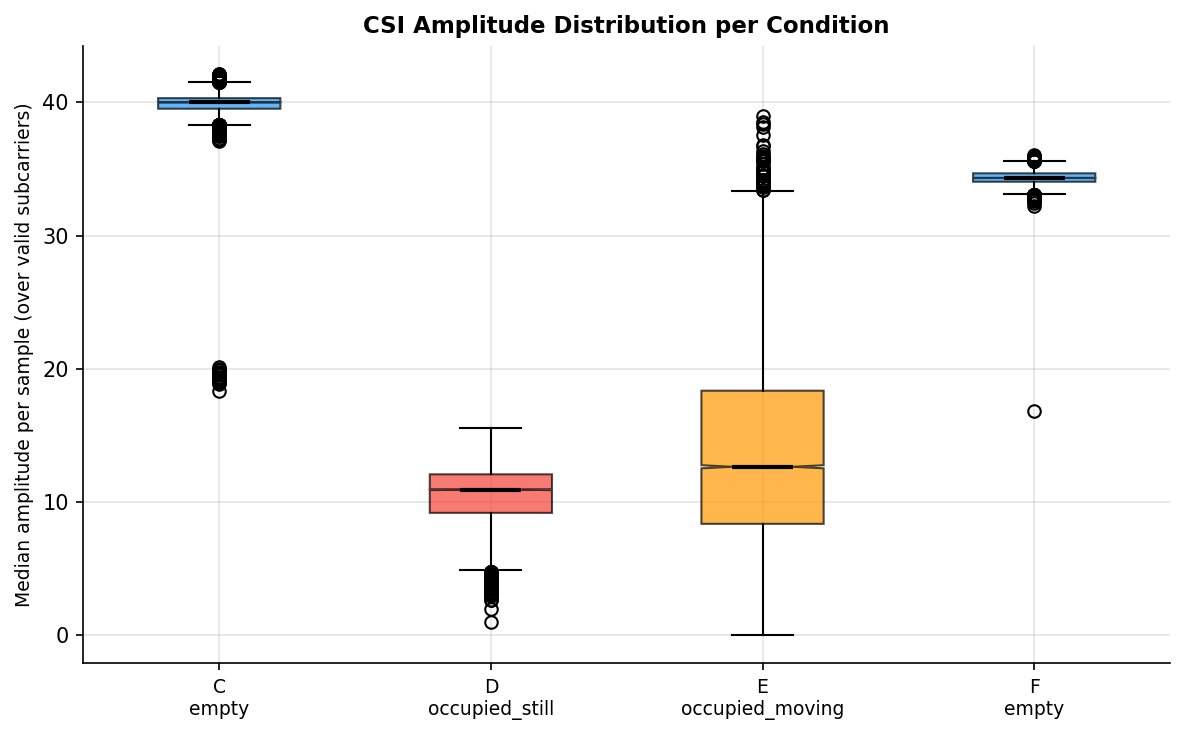

Saved: outputs/plot9_boxplot_amplitude.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

data_to_plot = []
labels_plot  = []
colors_plot  = []

for sid, s in sessions.items():
    amp_valid = s["csi_amp"][:, s["valid_mask"]]
    median_per_sample = np.median(amp_valid, axis=1)
    data_to_plot.append(median_per_sample)
    labels_plot.append(f"{sid}\n{s['label']}")
    colors_plot.append(get_color(s["label"]))

bp = ax.boxplot(data_to_plot, patch_artist=True, notch=True,
                medianprops=dict(color="black", lw=2))
for patch, color in zip(bp["boxes"], colors_plot):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(labels_plot, fontsize=9)
ax.set_ylabel("Median amplitude per sample (over valid subcarriers)", fontsize=9)
ax.set_title("CSI Amplitude Distribution per Condition", fontsize=11, fontweight="bold")

plt.tight_layout()
fpath = OUTPUT_DIR / "plot9_boxplot_amplitude.png"
plt.savefig(fpath, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {fpath}")


## Cell 14 - Viability Verdict and Sampling Rate Report

**Checklist items:**
- *Document effective sampling rate obtained*
- *Identify noisy subcarriers*

Automatic approval criteria: packet loss < 5%, rate within ±10% of nominal, RSSI std < 5 dBm, ≥ 40 valid subcarriers.

In [14]:

from scipy.stats import kurtosis as scipy_kurtosis

print("\n" + "="*65)
print("  FINAL REPORT - EXPERIMENTAL PILOT - Card 4")
print("  Collection dates: 2026-05-02 (sessions A–E), 2026-05-03 (session F)")
print("="*65)

all_pass = True

for sid, s in sessions.items():
    nom = get_nominal_rate(s)
    dt_nom = 1.0 / nom
    gaps = s["dt"][s["dt"] > 2.5 * dt_nom]
    lost_est = max(0, int(np.round(gaps.sum() / dt_nom)) - len(gaps))
    exp_pkts = int(np.round(s["duration_s"] * nom))
    loss_pct = 100 * lost_est / max(exp_pkts, 1)
    rate_err = abs(s["eff_rate_hz"] - nom) / nom

    checks = [
        ("Packet loss < 5%",              loss_pct < 5,       f"{loss_pct:.2f}%"),
        ("Eff. rate within +/-10% nominal", rate_err < 0.10,  f"{s['eff_rate_hz']:.3f} Hz  (nominal {nom:.0f} Hz)"),
        ("RSSI std < 5 dBm",              s["df"]["rssi"].std() < 5,
                                           f"{s['df']['rssi'].std():.2f} dBm"),
        (">= 40 valid subcarriers",        s["n_valid"] >= 40, f"{s['n_valid']} valid"),
    ]

    passed = all(ok for _, ok, _ in checks)
    all_pass = all_pass and passed
    status = "PASSED" if passed else "FAILED"

    print(f"\n  Session {sid} - {s['label']}  ->  {status}")
    print(f"  {'-'*50}")
    for desc, ok, detail in checks:
        icon = "[pass]" if ok else "[fail]"
        print(f"    {icon} {desc:<40} {detail}")
    print(f"  Effective rate         : {s['eff_rate_hz']:.3f} Hz")
    print(f"  Jitter (std IPI)       : {s['dt'].std()*1000:.2f} ms")
    print(f"  Valid subcarriers      : {s['n_valid']} / {s['n_subcarriers']}")
    print(f"  Active window duration : {s['duration_s']:.1f} s")

print("\n" + "="*65)
verdict = "PILOT APPROVED - proceed to full dataset collection." if all_pass else "PILOT WITH RESTRICTIONS - review failed sessions before proceeding."
print(f"\n  OVERALL VERDICT: {verdict}")
print("="*65)

# --- Anomalous subcarrier summary (all sessions) -----------------------------
print("\n-- Anomalous Subcarrier Summary --")
for sid, s in sessions.items():
    amp = s["csi_amp"]
    n_sub = amp.shape[1]
    mean_a = amp.mean(axis=0)
    std_a  = amp.std(axis=0)
    cv     = np.where(mean_a > 0.1, std_a / mean_a, np.nan)
    cv_valid = cv[s["valid_mask"]]
    thresh   = np.nanpercentile(cv_valid, 90) if len(cv_valid) > 0 else np.inf
    noisy    = np.where(s["valid_mask"] & (cv > thresh))[0]
    kurt     = np.array([scipy_kurtosis(amp[:, i], fisher=True) for i in range(n_sub)])
    anomalous = np.where(s["valid_mask"] & (np.abs(kurt) > 5))[0]
    print(f"  Session {sid}: noisy (CV>p90)={len(noisy)}, anomalous (|kurt|>5)={len(anomalous)}")

print("\nAnalysis complete. Figures saved to:", OUTPUT_DIR.resolve())



  FINAL REPORT - EXPERIMENTAL PILOT - Card 4
  Collection dates: 2026-05-02 (sessions A–E), 2026-05-03 (session F)

  Session C - empty  ->  PASSED
  --------------------------------------------------
    [pass] Packet loss < 5%                         0.16%
    [pass] Eff. rate within +/-10% nominal          28.390 Hz  (nominal 30 Hz)
    [pass] RSSI std < 5 dBm                         0.50 dBm
    [pass] >= 40 valid subcarriers                  166 valid
  Effective rate         : 28.390 Hz
  Jitter (std IPI)       : 7.41 ms
  Valid subcarriers      : 166 / 192
  Active window duration : 690.0 s

  Session D - occupied_still  ->  FAILED
  --------------------------------------------------
    [pass] Packet loss < 5%                         2.33%
    [fail] Eff. rate within +/-10% nominal          26.157 Hz  (nominal 30 Hz)
    [pass] RSSI std < 5 dBm                         1.57 dBm
    [pass] >= 40 valid subcarriers                  162 valid
  Effective rate         : 26.157 Hz
  